# MIMIC-IV-ED Dataset

Nome: Vinicius Anjos de Almeida

Número USP: 7625114

## Descrição
MIMIC-IV-ED é um grande dataset disponível gratuitamente, contendo visitas ao departamento de emergência (ED) do Beth Israel Deaconess Medical Center entre 2011 e 2019. O banco de dados contém aproximadamente 425.000 passagens no ED. Vários dados dessas passagens estão disponíveis, incluindo sinais vitais, informações de triagem, medicamentos que o paciente utilizava até antes da internação e se o paciente foi internado no hospital ou não. 

## Plano
Utilizar dados disponíveis logo após a avaliação na triagem para prever se o paciente será internado no hospital ou não naquela visita. As informações que estarão disponíveis neste momento são:
- raça
- gênero
- idade
- o meio pelo qual o paciente chegou ao hospital
- data e hora da entrada no hospital
- medicamentos em uso até antes da visita ao serviço de emergência
  - Número de medicamentos em uso
  - Código nacional de cada medicamento em uso
- sinais vitais e outras avaliações objetivas, incluindo:
  - temperatura
  - frequência cardíaca
  - frequência respiratória
  - saturação de O2
  - pressão arterial sistólica
  - pressão arterial diastólica
  - nível de dor
- nível de urgência, que é um número de 1 a 5 representando o nível de urgência do caso com base na impressão do profissional que executou a triagem. 1 representa a maior gravidade e 5 a menor gravidade.

Modelos de machine learning para testar e otimizar para a tarefa:
- Random Forest
- XGBoost
- Light GBM
- CatBoost
- Multilayer perceptron

Trabalhos anteriores não incluíram informações sobre medicamentos e excluíram dados faltantes. Neste contexto, medicamentos e dados faltantes podem revelar informações importantes sobre a gravidade do quadro do paciente e, por isso, serão incluídos aqui. Além disso, a coluna 'disposition' em geral foi a utilizada para saber se o paciente internou ou não, porém essa coluna eventualmente tem informações discordantes da coluna hadm_id, que é a coluna com o id propriamente da internação hospitalar e que se relaciona com a tabela com dados das internações hospitalares. Por esse motivo, utilzaremos como indicador da internação a existência de um id na coluna  'hadm_id'.

## Trabalhos anteriores

---

**A Machine Learning Pipeline Using KNIME to Predict Hospital Admission in the MIMIC-IV Database**

**Abstract:**
It is well known that overcrowding in emergency department (ED) lowers the standard of care and raises the risk of medical errors. An initial predictive supplementary tool of hospital admission at an early stage of a patient's arrival to the emergency department (ED) can provide health care professionals a number of advantages, such as, more efficient patient flow management and better hospital care. In this paper, we use data from the Medical Information Mart for Intensive Care IV Emergency Department (MIMIC-IV-ED) database to predict whether a patient will be admitted to the hospital or not. The choice of predictive attributes was driven by simplicity (a set of basic vital signs were used) so that the prediction can be made at an early stage of the patient's arrival. Several versions of Machine Learning (ML) algorithms based on Decision Trees (DT) were used for classification and prediction. An important asset of the proposed methodology is that the whole process is implemented through an ML pipeline created with an open-source, visual programming tool. The proposed methodology contains the pre-processing stage, the modelling stage includes seven classifiers, and the combined visualization of the evaluation of the predictive models. The Gradient Boosted Trees method outperforms the rest of the algorithms that were used. An accuracy of 80% can be achieved only by using early triage data.

**URL:** https://ieeexplore.ieee.org/document/10345903

---
**Machine Learning in Medical Triage: A Predictive Model for Emergency Department Disposition**

**Abstract:**
The study explores the application of automated machine learning (AutoML) using the MIMIC-IV-ED database to enhance decision-making in emergency department (ED) triage. We developed a predictive model that utilizes triage data to forecast hospital admissions, aiming to support medical staff by providing an advanced decision-support system. The model, powered by H2O.ai’s AutoML platform, was trained on approximately 280,000 preprocessed records from the Beth Israel Deaconess Medical Center collected between 2011 and 2019. The selected Gradient Boosting Machine (GBM) model demonstrated an AUC ROC of 0.8256, indicating its efficacy in predicting patient dispositions. Key variables such as acuity and waiting hours were identified as significant predictors, emphasizing the model’s capability to integrate critical triage metrics into its predictions. However, challenges related to the complexity and heterogeneity of medical data, privacy concerns, and the need for model interpretability were addressed through the incorporation of Explainable AI (XAI) techniques. These techniques ensure the transparency of the predictive processes, fostering trust and facilitating ethical AI use in clinical settings. Future work will focus on external validation and expanding the model to include a broader array of variables from diverse healthcare environments, enhancing the model’s utility and applicability in global emergency care contexts.

**URL:** https://www.mdpi.com/2076-3417/14/15/6623

---

In [1]:
#Comandos que fazem o download do dataset. Acesso já está autorizado via plataforma Physionet

#!wget -r -N -c -np --user almeidava93 --ask-password https://physionet.org/files/mimic-iv-ed/2.2/ -q
#!wget -r -N -c -np --user almeidava93 --ask-password https://physionet.org/files/mimiciv/3.0/hosp/patients.csv.gz -q

In [2]:
# Após download de arquivos comprimidos em .gz, descomprimir para ter acesso aos csv

import os
from pathlib import Path
import gzip
import shutil

cwd = Path(os.getcwd())

for (root,dirs,files) in os.walk(cwd/'physionet.org'):
  for file in files:
    if file.endswith('.gz'):
      compressed_file_path = Path(root, file)
      decompressed_file_path = Path(root, file[:-3])

      with gzip.open(compressed_file_path, 'rb') as f1:
        with open(decompressed_file_path, 'wb') as f2:
          shutil.copyfileobj(f1, f2)

      os.remove(compressed_file_path)
      print(f"File {decompressed_file_path} decompressed.")

In [3]:
# Carregar DataFrames com todas as tabelas

import pandas as pd

edstays_path = Path('physionet.org/files/mimic-iv-ed/2.2/ed/edstays.csv')
edstays_df = pd.read_csv(edstays_path)

diagnosis_path = Path('physionet.org/files/mimic-iv-ed/2.2/ed/diagnosis.csv')
diagnosis_df = pd.read_csv(diagnosis_path)

medrecon_path = Path('physionet.org/files/mimic-iv-ed/2.2/ed/medrecon.csv')
medrecon_df = pd.read_csv(medrecon_path)

pyxis_path = Path('physionet.org/files/mimic-iv-ed/2.2/ed/pyxis.csv')
pyxis_df = pd.read_csv(pyxis_path)

triage_path = Path('physionet.org/files/mimic-iv-ed/2.2/ed/triage.csv')
triage_df = pd.read_csv(triage_path)

vitalsign_path = Path('physionet.org/files/mimic-iv-ed/2.2/ed/vitalsign.csv')
vitalsign_df = pd.read_csv(vitalsign_path)

patients_path = Path('physionet.org/files/mimiciv/3.0/hosp/patients.csv')
patients_df = pd.read_csv(patients_path)

In [4]:
edstays_df.head()

,subject_id,hadm_id,stay_id,intime,outtime,gender,race,arrival_transport,disposition
0,10000032,22595853.0,33258284,2180-05-06 19:17:00,2180-05-06 23:30:00,F,WHITE,AMBULANCE,ADMITTED
1,10000032,22841357.0,38112554,2180-06-26 15:54:00,2180-06-26 21:31:00,F,WHITE,AMBULANCE,ADMITTED
2,10000032,25742920.0,35968195,2180-08-05 20:58:00,2180-08-06 01:44:00,F,WHITE,AMBULANCE,ADMITTED
3,10000032,29079034.0,32952584,2180-07-22 16:24:00,2180-07-23 05:54:00,F,WHITE,AMBULANCE,HOME
4,10000032,29079034.0,39399961,2180-07-23 05:54:00,2180-07-23 14:00:00,F,WHITE,AMBULANCE,ADMITTED


In [5]:
patients_df.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13


In [6]:
# Organizar DataFrame único com dados de interesse
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer


data_df = pd.DataFrame()
data_df["id"] = edstays_df["stay_id"]
data_df["subject_id"] = edstays_df["subject_id"]

# Codificar dados categóricos
## Selecionar variáveis categóricas
data_df["gender"] = edstays_df["gender"]
data_df["race"] = edstays_df["race"]
data_df["arrival_transport"] = edstays_df["arrival_transport"]
categoric_cols = ["gender", "race", "arrival_transport"]
## Criar one-hot encoding de variáveis categóricas
data_df = pd.get_dummies(data_df, columns=categoric_cols)

# Incluir informações sobre a hora, o dia da semana e o mês do ano em que a visita ao serviço de emergência ocorreu
data_df['intime'] = pd.to_datetime(edstays_df['intime'])
data_df['in_day_of_the_week'] = data_df['intime'].dt.day_of_week
data_df['in_hour_of_the_day'] = data_df['intime'].dt.hour
data_df['in_month_of_the_year'] = data_df['intime'].dt.month

# Circular encoding - Padronizar dados cíclicos para representar melhor a ciclicidade presente no dado
## Selecionar variáveis cíclicas
cyclic_cols = ['in_day_of_the_week', 'in_hour_of_the_day', 'in_month_of_the_year']
## Realizar circular encoding para cada variável
for col in cyclic_cols:
  data_df[f'{col}_sin'] = np.sin(2 * np.pi * data_df[col] / len(data_df[col].unique()))
  data_df[f'{col}_cos'] = np.cos(2 * np.pi * data_df[col] / len(data_df[col].unique()))
## Deletar colunas originais
data_df.drop(columns=cyclic_cols, inplace=True)

# Incluir se o paciente foi admitido ao hospital ou não
data_df['admitted_to_hosp'] = edstays_df['hadm_id'].apply(lambda x: np.isnan(x)==False).astype(int)

# Incluir dados coletados na triagem do hospital
## Seleção das variáveis relevantes
triage_data_df = triage_df[['stay_id', 'temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'acuity', 'pain']]

## Conversão dos dados da coluna pain para dado numérico inteiro quando possível. Se não é possível, deixar como missing.
def convert_to_int(value):
    try:
        return int(value)
    except:
        return np.nan
    
triage_data_df['pain'] = triage_data_df['pain'].apply(convert_to_int)

## União das tabelas
data_df = pd.merge(data_df, triage_data_df, left_on='id', right_on='stay_id', how='left')

# Incluir dado de idade do paciente ('anchor_age')
patients_age_df = patients_df[['subject_id', 'anchor_age']]
## União das tabelas através do id do paciente
data_df = pd.merge(data_df, patients_age_df, left_on='subject_id', right_on='subject_id', how='left')

# Tratar dados faltantes
## Criar coluna com one-hot encoding definindo se existe valor faltando ou não para aquela variável
cols_with_missing_values = []
for col in data_df.columns:
  if data_df[col].isna().any():
    cols_with_missing_values.append(col)
    data_df[f'{col}_is_missing'] = data_df[col].isna().astype(int)

# Reunir dados relativos os medicamentos que os pacientes faziam uso até antes de passarem na emergência
# Reunir por cada código disponível, que considera princípio ativo e grupo de medicamentos
# Pegar lista de códigos NDC (National Drug Code) de medicamentos e associar a cada stay_id
med_by_stay_id_ndc = medrecon_df.groupby('stay_id')['ndc'].unique()
data_df = pd.merge(data_df, med_by_stay_id_ndc, left_on='id', right_on='stay_id', how='left')

# Pegar lista de códigos etccode de medicamentos e associar a cada stay_id
med_by_stay_id_etccode = medrecon_df.groupby('stay_id')['etccode'].unique()
data_df = pd.merge(data_df, med_by_stay_id_etccode, left_on='id', right_on='stay_id', how='left')

# Pegar lista de códigos Generic Sequence Number (GSN) de medicamentos e associar a cada stay_id
med_by_stay_id_gsn = medrecon_df.groupby('stay_id')['gsn'].unique()
data_df = pd.merge(data_df, med_by_stay_id_gsn, left_on='id', right_on='stay_id', how='left')

# Pegar lista nomes de medicamentos e associar a cada stay_id
med_by_stay_id_name = medrecon_df.groupby('stay_id')['name'].unique()
data_df = pd.merge(data_df, med_by_stay_id_name, left_on='id', right_on='stay_id', how='left')


C:\Users\Vinicius\AppData\Local\Temp\ipykernel_30124\2926409353.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  triage_data_df['pain'] = triage_data_df['pain'].apply(convert_to_int)


In [7]:
# Incluir número de medicamentos que o paciente usava antes da passagem na emergência
# Vamos incluir a contagem de medicamentos segundo cada coluna, já que elas podem ter valores diferentes por conta de se tratar uma codificação diferente

import numpy as np

def get_len(list):
    if list is np.nan:
        return 0
    else:
        return len(list)

# Pegar o número de medicamentos segundo códigos NDC únicos 
data_df['med_count_by_ndc'] = data_df['ndc'].apply(get_len)

In [8]:
# Criar coluna enfatizando o fato de o paciente não usar nenhuma medicação continuamente até o momento da passagem na emergência
data_df['use_no_medication'] = data_df['med_count_by_ndc']==0

In [9]:
# Preparar datasets
random_state = 42
## Separar variáveis preditoras da variável a ser predita
X = data_df.drop('admitted_to_hosp', axis=1)
y = data_df['admitted_to_hosp']
## Separar em dataset de treino (90%) e teste (10%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=random_state)
## Separar dados de treino em treino (90%) e validação (10%)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=random_state)

### Target encoding de medicamentos
Proporções de internações calculadas com base em:
- códigos NDC - National Drug Code

In [10]:
# Separar dados de medicamentos para target encoding utilizando dados do dataset de treino
medrecon_train_df = medrecon_df[medrecon_df["stay_id"].isin(X_train["id"])]

#### Proporção de admissões por código NDC de medicamentos

In [11]:
# Agrupar medicamentos por código NDC presentes no dataset de treino e as passagens na emergência
med_adm_prop_by_ndc = medrecon_train_df.groupby('ndc')['stay_id'].unique().reset_index()

# Calcular a proporção das passagens na emergência em que havia uso do medicamento com um nome específico e que terminaram em admissão hospitalar
med_adm_prop_by_ndc['admission_proportion_by_ndc'] = med_adm_prop_by_ndc['stay_id'].apply(
    lambda stay_ids: edstays_df[edstays_df["stay_id"].isin(stay_ids)]['hadm_id'].notna().mean()
)
# med_adm_prop_by_ndc é a referência para a proporção de admissão relacionada a cada medicamento
med_adm_prop_by_ndc.drop(columns=['stay_id'], inplace=True)

# Usar chance de admissão geral dos dados de treino caso não haja medicamentos em uso com código NDC
general_admission_proportion = y_train.value_counts(normalize=True).iloc[1]

In [12]:
# Definir função que estima chance de internação baseada nos códigos NDC.
def estimate_mean_admission_proportion_by_ndc(ndc_list):
  if ndc_list is None or ndc_list is np.nan:
    return general_admission_proportion
  # Entre os medicamentos em uso, selecionar o valor correspondente à média das chances de internação de cada medicamento
  return med_adm_prop_by_ndc[med_adm_prop_by_ndc['ndc'].isin(ndc_list)]['admission_proportion_by_ndc'].mean()

X_train['ndc_mean_adm_prop'] = X_train['ndc'].apply(estimate_mean_admission_proportion_by_ndc)
X_val['ndc_mean_adm_prop'] = X_val['ndc'].apply(estimate_mean_admission_proportion_by_ndc)
X_test['ndc_mean_adm_prop'] = X_test['ndc'].apply(estimate_mean_admission_proportion_by_ndc)

#### Inspecionar dados numéricos com base nos dados de treino

In [13]:
## Selecionar dados numéricos
numeric_cols = ['anchor_age','temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'acuity', 'pain', 'ndc_mean_adm_prop', 'med_count_by_ndc']

In [14]:
X_train[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
anchor_age,344256.0,50.345641,20.094372,18.0,32.000000,50.000000,66.000000,91.0
temperature,325344.0,98.020863,4.270164,0.1,97.500000,98.000000,98.600000,986.0
heartrate,330470.0,85.080623,18.066636,1.0,72.000000,84.000000,96.000000,1228.0
resprate,327789.0,17.558600,4.033645,0.0,16.000000,18.000000,18.000000,1797.9
o2sat,327689.0,98.488460,18.762757,0.0,97.000000,99.000000,100.000000,9322.0
sbp,329493.0,135.470411,266.993993,1.0,120.000000,133.000000,148.000000,151103.0
dbp,328840.0,81.454166,1163.365824,0.0,68.000000,77.000000,87.000000,661672.0
acuity,338559.0,2.625070,0.707989,1.0,2.000000,3.000000,3.000000,5.0
pain,321121.0,4.420524,4.068748,-1.0,0.000000,5.000000,8.000000,134.0
ndc_mean_adm_prop,344320.0,0.563357,0.086407,0.0,0.477605,0.580434,0.629807,1.0


##### Investigar colinearidade

In [15]:
corr = X_train[numeric_cols].corr()
corr

,anchor_age,temperature,heartrate,resprate,o2sat,sbp,dbp,acuity,pain,ndc_mean_adm_prop,med_count_by_ndc
anchor_age,1.000000,-0.015840,-0.159401,0.066058,-0.027141,0.014907,-0.002533,-0.241425,-0.132845,0.488063,0.410057
temperature,-0.015840,1.000000,0.045860,0.006974,-0.000538,0.027113,-0.000176,-0.002458,0.009978,-0.004583,-0.005272
heartrate,-0.159401,0.045860,1.000000,0.086059,-0.007997,0.000693,0.000942,-0.117043,0.030201,-0.042012,-0.033937
resprate,0.066058,0.006974,0.086059,1.000000,-0.005724,0.001102,-0.000174,-0.107070,0.004781,0.056804,0.071854
o2sat,-0.027141,-0.000538,-0.007997,-0.005724,1.000000,0.000416,0.000197,0.021394,0.004719,-0.017047,-0.017593
sbp,0.014907,0.027113,0.000693,0.001102,0.000416,1.000000,0.003648,0.002177,0.002176,0.007131,0.004454
dbp,-0.002533,-0.000176,0.000942,-0.000174,0.000197,0.003648,1.000000,0.000919,0.001569,-0.000215,-0.002065
acuity,-0.241425,-0.002458,-0.117043,-0.107070,0.021394,0.002177,0.000919,1.000000,0.131784,-0.193716,-0.151300
pain,-0.132845,0.009978,0.030201,0.004781,0.004719,0.002176,0.001569,0.131784,1.000000,-0.072383,-0.015568
ndc_mean_adm_prop,0.488063,-0.004583,-0.042012,0.056804,-0.017047,0.007131,-0.000215,-0.193716,-0.072383,1.000000,0.557887


<Axes: >

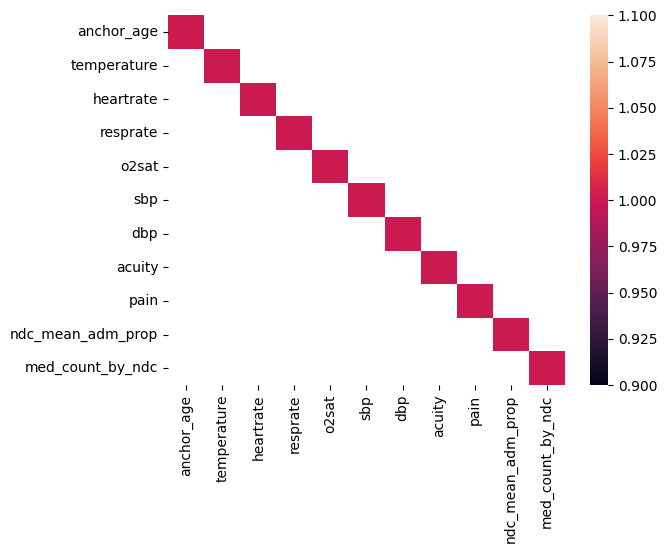

In [16]:
# Visualizar variáveis com alta colinearidade (acima de 0.7)
import seaborn as sns

sns.heatmap(corr[corr>0.7])

In [17]:
# Selecionar os nomes das variáveis com alta colinearidade
upper = corr.where(np.triu(np.ones(corr.abs().shape), k=1).astype(bool))
high_corr_features = [column for column in upper.columns if any(upper[column] > 0.9)]


In [18]:
high_corr_features

[]

##### Boxplots

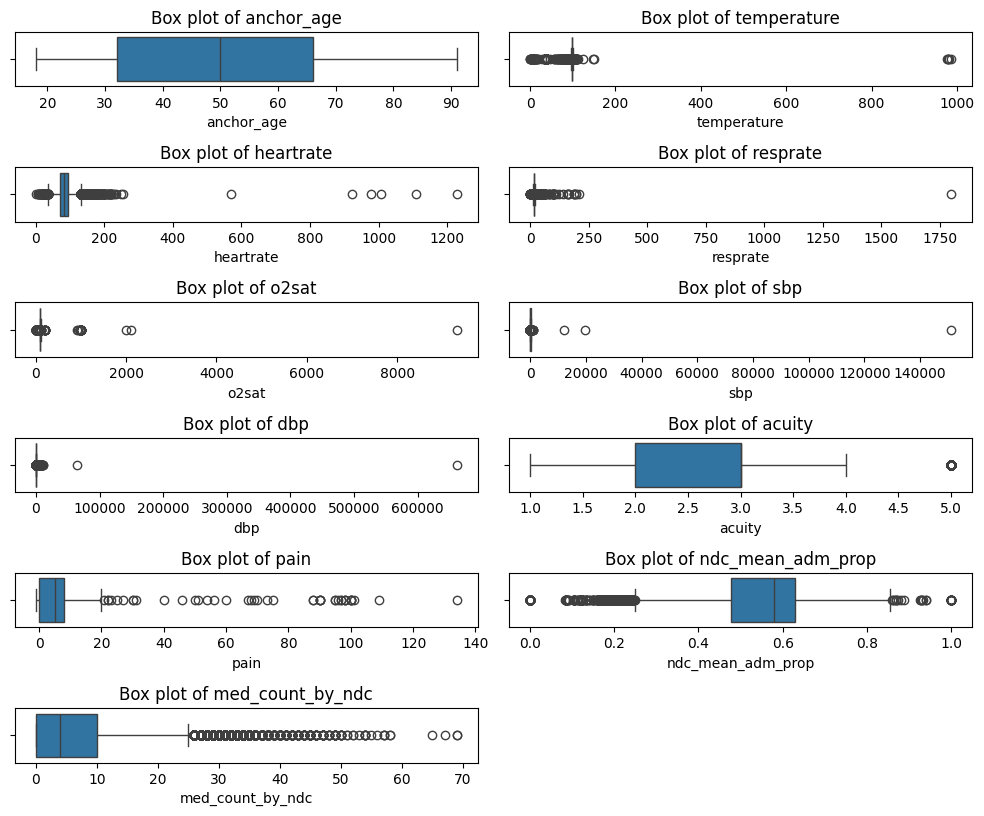

In [20]:
# Criar plot para inspecionar distribuição de dados numéricos e identificar anomalias

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 20))

for i, feature in enumerate(numeric_cols, 1):
    plt.subplot(15, 2, i)  
    sns.boxplot(x=X_train[feature])
    plt.title(f'Box plot of {feature}')

plt.tight_layout()
plt.show()

In [21]:
# Ajustar valores claramente equivocados nas variáveis
## temperature
X_train.loc[X_train['temperature'] > 200, 'temperature'] = np.nan
X_val.loc[X_val['temperature'] > 200, 'temperature'] = np.nan
X_test.loc[X_test['temperature'] > 200, 'temperature'] = np.nan

In [22]:
## heartrate
X_train.loc[X_train['heartrate'] > 400, 'heartrate'] = np.nan
X_val.loc[X_val['heartrate'] > 400, 'heartrate'] = np.nan
X_test.loc[X_test['heartrate'] > 400, 'heartrate'] = np.nan

In [23]:
## resprate
X_train.loc[X_train['resprate'] > 60, 'resprate'] = np.nan
X_val.loc[X_val['resprate'] > 60, 'resprate'] = np.nan
X_test.loc[X_test['resprate'] > 60, 'resprate'] = np.nan

In [24]:
## o2sat
X_train.loc[X_train['o2sat'] > 100, 'o2sat'] = np.nan
X_val.loc[X_val['o2sat'] > 100, 'o2sat'] = np.nan
X_test.loc[X_test['o2sat'] > 100, 'o2sat'] = np.nan

In [25]:
## sbp
X_train.loc[X_train['sbp'] > 300, 'sbp'] = np.nan
X_val.loc[X_val['sbp'] > 300, 'sbp'] = np.nan
X_test.loc[X_test['sbp'] > 300, 'sbp'] = np.nan

In [26]:
## dbp
X_train.loc[X_train['dbp'] > 300, 'dbp'] = np.nan
X_val.loc[X_val['dbp'] > 300, 'dbp'] = np.nan
X_test.loc[X_test['dbp'] > 300, 'dbp'] = np.nan

In [27]:
## pain - Considerar apenas valores entre 0 e 10
X_train.loc[(X_train['pain'] > 10)|(X_train['pain'] < 0), 'pain'] = np.nan
X_val.loc[(X_val['pain'] > 10)|(X_val['pain'] < 0), 'pain'] = np.nan
X_test.loc[(X_test['pain'] > 10)|(X_test['pain'] < 0), 'pain'] = np.nan

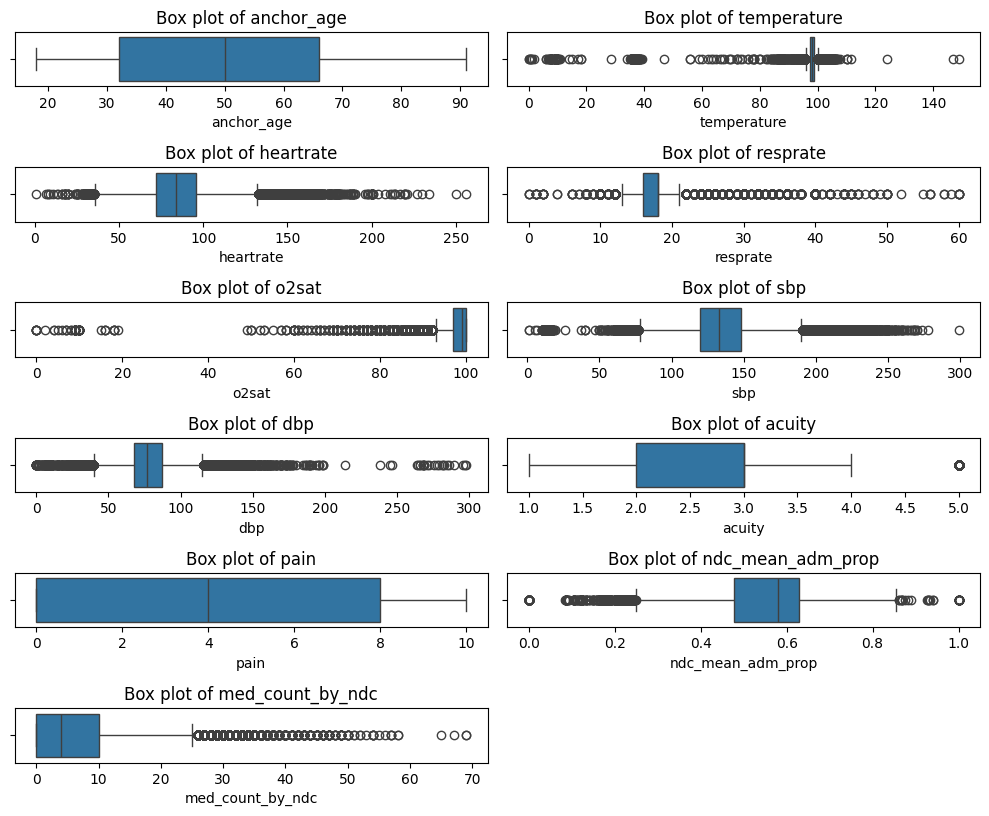

In [28]:
# Criar plot para inspecionar novamente após as modificações

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 20))

for i, feature in enumerate(numeric_cols, 1):
    plt.subplot(15, 2, i)  
    sns.boxplot(x=X_train[feature])
    plt.title(f'Box plot of {feature}')

plt.tight_layout()
plt.show()

#### Realizar padronização dos dados segundo dados de treino

In [29]:
# Normalizar dados numéricos
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
## Dados de treino
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
## Aplicar o mesmo scaler aos dados de validação e teste
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


#### Inspeção dos dados categóricos

In [30]:
bool_cols = X_train.select_dtypes(include='bool').columns

# tabelas de frequências com porcentagens, se quiser com frequencias absolutas tirar o normalize
for col in bool_cols:
    print(X_train[col].value_counts(normalize=True).sort_index(), end='\n\n')

gender_F
False    0.459061
True     0.540939
Name: proportion, dtype: float64

gender_M
False    0.540939
True     0.459061
Name: proportion, dtype: float64

race_AMERICAN INDIAN/ALASKA NATIVE
False    0.997505
True     0.002495
Name: proportion, dtype: float64

race_ASIAN
False    0.98276
True     0.01724
Name: proportion, dtype: float64

race_ASIAN - ASIAN INDIAN
False    0.996364
True     0.003636
Name: proportion, dtype: float64

race_ASIAN - CHINESE
False    0.982752
True     0.017248
Name: proportion, dtype: float64

race_ASIAN - KOREAN
False    0.998147
True     0.001853
Name: proportion, dtype: float64

race_ASIAN - SOUTH EAST ASIAN
False    0.996341
True     0.003659
Name: proportion, dtype: float64

race_BLACK/AFRICAN
False    0.988577
True     0.011423
Name: proportion, dtype: float64

race_BLACK/AFRICAN AMERICAN
False    0.819104
True     0.180896
Name: proportion, dtype: float64

race_BLACK/CAPE VERDEAN
False    0.981906
True     0.018094
Name: proportion, dtype: float64



#### Eliminar colunas que serão excluídas da análise

In [31]:
# Eliminar colunas que não serão utilizadas na análise
cols_to_drop = ['intime','stay_id','subject_id','id','gsn','ndc','etccode','name',
                #Colunas que serão excluídas por alta colinearidade
                *high_corr_features]
datasets = [X_train, X_val, X_test]
for dataset in datasets:
  dataset.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print("Train set size:", X_train.shape)
print("Validation set size:", X_val.shape)
print("Test set size:", X_test.shape)


Train set size: (344320, 67)
Validation set size: (38258, 67)
Test set size: (42509, 67)


In [32]:
X_train.columns

Index(['gender_F', 'gender_M', 'race_AMERICAN INDIAN/ALASKA NATIVE',
       'race_ASIAN', 'race_ASIAN - ASIAN INDIAN', 'race_ASIAN - CHINESE',
       'race_ASIAN - KOREAN', 'race_ASIAN - SOUTH EAST ASIAN',
       'race_BLACK/AFRICAN', 'race_BLACK/AFRICAN AMERICAN',
       'race_BLACK/CAPE VERDEAN', 'race_BLACK/CARIBBEAN ISLAND',
       'race_HISPANIC OR LATINO', 'race_HISPANIC/LATINO - CENTRAL AMERICAN',
       'race_HISPANIC/LATINO - COLUMBIAN', 'race_HISPANIC/LATINO - CUBAN',
       'race_HISPANIC/LATINO - DOMINICAN', 'race_HISPANIC/LATINO - GUATEMALAN',
       'race_HISPANIC/LATINO - HONDURAN', 'race_HISPANIC/LATINO - MEXICAN',
       'race_HISPANIC/LATINO - PUERTO RICAN',
       'race_HISPANIC/LATINO - SALVADORAN', 'race_MULTIPLE RACE/ETHNICITY',
       'race_NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER', 'race_OTHER',
       'race_PATIENT DECLINED TO ANSWER', 'race_PORTUGUESE',
       'race_SOUTH AMERICAN', 'race_UNABLE TO OBTAIN', 'race_UNKNOWN',
       'race_WHITE', 'race_WHITE - B

#### Realizar substituição de dados faltantes com a média dos dados no dataset de treino

In [33]:
# Realizar substuição de dados faltantes com a média dos dados no dataset de treino
imputer = SimpleImputer(strategy='mean')
## Preparar imputer com dados de treino
cols_with_missing_values = [col for col in set([*cols_with_missing_values, *numeric_cols]) if col in X_train.columns]
imputer.fit(X_train[cols_with_missing_values])
## Aplicar em todos os datasets (treino, validação e teste)
X_train[cols_with_missing_values] = imputer.transform(X_train[cols_with_missing_values])
X_val[cols_with_missing_values] = imputer.transform(X_val[cols_with_missing_values])
X_test[cols_with_missing_values] = imputer.transform(X_test[cols_with_missing_values])

In [34]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 344320 entries, 235356 to 241375
Data columns (total 67 columns):
 #   Column                                          Non-Null Count   Dtype  
---  ------                                          --------------   -----  
 0   gender_F                                        344320 non-null  bool   
 1   gender_M                                        344320 non-null  bool   
 2   race_AMERICAN INDIAN/ALASKA NATIVE              344320 non-null  bool   
 3   race_ASIAN                                      344320 non-null  bool   
 4   race_ASIAN - ASIAN INDIAN                       344320 non-null  bool   
 5   race_ASIAN - CHINESE                            344320 non-null  bool   
 6   race_ASIAN - KOREAN                             344320 non-null  bool   
 7   race_ASIAN - SOUTH EAST ASIAN                   344320 non-null  bool   
 8   race_BLACK/AFRICAN                              344320 non-null  bool   
 9   race_BLACK/AFRICAN AMERICA

In [35]:
X_train.columns

Index(['gender_F', 'gender_M', 'race_AMERICAN INDIAN/ALASKA NATIVE',
       'race_ASIAN', 'race_ASIAN - ASIAN INDIAN', 'race_ASIAN - CHINESE',
       'race_ASIAN - KOREAN', 'race_ASIAN - SOUTH EAST ASIAN',
       'race_BLACK/AFRICAN', 'race_BLACK/AFRICAN AMERICAN',
       'race_BLACK/CAPE VERDEAN', 'race_BLACK/CARIBBEAN ISLAND',
       'race_HISPANIC OR LATINO', 'race_HISPANIC/LATINO - CENTRAL AMERICAN',
       'race_HISPANIC/LATINO - COLUMBIAN', 'race_HISPANIC/LATINO - CUBAN',
       'race_HISPANIC/LATINO - DOMINICAN', 'race_HISPANIC/LATINO - GUATEMALAN',
       'race_HISPANIC/LATINO - HONDURAN', 'race_HISPANIC/LATINO - MEXICAN',
       'race_HISPANIC/LATINO - PUERTO RICAN',
       'race_HISPANIC/LATINO - SALVADORAN', 'race_MULTIPLE RACE/ETHNICITY',
       'race_NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER', 'race_OTHER',
       'race_PATIENT DECLINED TO ANSWER', 'race_PORTUGUESE',
       'race_SOUTH AMERICAN', 'race_UNABLE TO OBTAIN', 'race_UNKNOWN',
       'race_WHITE', 'race_WHITE - B

In [ ]:
X_train.head(10)

,gender_F,gender_M,race_AMERICAN INDIAN/ALASKA NATIVE,race_ASIAN,race_ASIAN - ASIAN INDIAN,race_ASIAN - CHINESE,race_ASIAN - KOREAN,race_ASIAN - SOUTH EAST ASIAN,race_BLACK/AFRICAN,race_BLACK/AFRICAN AMERICAN,...,resprate_is_missing,o2sat_is_missing,sbp_is_missing,dbp_is_missing,acuity_is_missing,pain_is_missing,anchor_age_is_missing,med_count_by_ndc,use_no_medication,ndc_mean_adm_prop
235356,True,False,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,-0.745889,False,-3.908585
59383,True,False,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,3.684250,False,0.499843
171985,False,True,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0.583152,False,1.752079
377339,False,True,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,-0.302875,False,0.751444
338611,True,False,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,2.798222,False,0.751533
16415,False,True,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,-0.893561,True,-0.992414
74161,False,True,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0.140138,False,0.729309
192571,True,False,False,False,False,False,False,False,False,False,...,0,0,0,0,0,1,0,-0.893561,True,-0.992414
346646,False,True,False,False,False,False,False,False,False,True,...,0,0,0,0,0,0,0,1.026166,False,0.106234
192043,True,False,False,False,False,False,False,False,False,True,...,0,0,0,0,0,1,0,-0.893561,True,-0.992414


In [36]:
# Salvar no disco os datasets
X_train.to_csv(Path('cleaned_data', 'X_train.csv'))
X_val.to_csv(Path('cleaned_data', 'X_val.csv'))
X_test.to_csv(Path('cleaned_data', 'X_test.csv'))

y_train.to_csv(Path('cleaned_data', 'y_train.csv'))
y_val.to_csv(Path('cleaned_data', 'y_val.csv'))
y_test.to_csv(Path('cleaned_data', 'y_test.csv'))

# Treinamento dos modelos

In [1]:
# Carregar dados

import pandas as pd
from pathlib import Path

X_train = pd.read_csv(Path('cleaned_data','X_train.csv'), index_col=0)
X_val = pd.read_csv(Path('cleaned_data','X_val.csv'), index_col=0)
X_test = pd.read_csv(Path('cleaned_data','X_test.csv'), index_col=0)

y_train = pd.read_csv(Path('cleaned_data','y_train.csv'), index_col=0)
y_val = pd.read_csv(Path('cleaned_data','y_val.csv'), index_col=0)
y_test = pd.read_csv(Path('cleaned_data','y_test.csv'), index_col=0)

In [2]:
# Importar bibliotecas relevantes

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score

from tabpfn import TabPFNClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats
import numpy as np
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import roc_curve, auc


## Random forest

In [41]:
random_state = 42

# Definição do modelo
rf = RandomForestClassifier()

# Definição dos intervalos de hiperparâmetros para busca dos melhores 
param_dist = {
    'max_depth': stats.randint(3, 10),
    'min_samples_split': stats.uniform(),
    'min_samples_leaf': stats.uniform(),
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False],
    'n_estimators':stats.randint(100, 1000, ),
}

# Realizar busca aleatória dos melhores hiperparâmetros
# Create the RandomizedSearchCV object
random_search = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=50, cv=10, scoring='roc_auc', n_jobs=-1, random_state=random_state)

# Fit the RandomizedSearchCV object to the training data
random_search.fit(X_train, y_train.values.ravel())

# Print the best set of hyperparameters and the corresponding score
print("Best set of hyperparameters: ", random_search.best_params_)
print("Best score: ", random_search.best_score_)

Best set of hyperparameters:  {'bootstrap': False, 'max_depth': 6, 'max_features': 'log2', 'min_samples_leaf': 0.009197051616629648, 'min_samples_split': 0.1014715428660321, 'n_estimators': 198}
Best score:  0.8064081505324341


In [42]:
# Selecionar melhor modelo
rf = random_search.best_estimator_
rf

RandomForestClassifier(bootstrap=False, max_depth=6, max_features='log2',
                       min_samples_leaf=0.009197051616629648,
                       min_samples_split=0.1014715428660321, n_estimators=198)

In [8]:
# Definir função para avaliar performance do modelo no dataset de validação e de teste

def eval(model, model_name: str, dataset_name: str, X: pd.DataFrame, y: pd.DataFrame):
    prob_pos = model.predict_proba(X)[:, 1]
    y_pred = model.predict(X)

    print(f'{model_name} Model - {dataset_name} dataset')
    print("Accuracy: {:.4f}".format(accuracy_score(y, y_pred)))
    print("Precision: {:.4f}".format(precision_score(y, y_pred)))
    print("Recall: {:.4f}".format(recall_score(y, y_pred)))
    print("AUC: {:.4f}".format(roc_auc_score(y, prob_pos)))
    print(classification_report(y, y_pred))

In [44]:
# Avaliar performance no dataset de validação
eval(rf, model_name="Random Forest", dataset_name="Validation", X=X_val, y=y_val)

Random Forest Model - Validation dataset
Accuracy: 0.7317
Precision: 0.7282
Recall: 0.6969
AUC: 0.8038
              precision    recall  f1-score   support

           0       0.73      0.76      0.75     20036
           1       0.73      0.70      0.71     18222

    accuracy                           0.73     38258
   macro avg       0.73      0.73      0.73     38258
weighted avg       0.73      0.73      0.73     38258



In [49]:
# Após algumas iterações, treinar modelo final para avaliação no teste usando dados disponíveis nos datasets de treino e validação. 

# Definição do modelo
rf_final = RandomForestClassifier(**random_search.best_params_)

# Treinar com dados de treino e validação
rf_final.fit(
    X = pd.concat([X_train, X_val]),
    y = pd.concat([y_train, y_val]).values.ravel()
)


RandomForestClassifier(bootstrap=False, max_depth=6, max_features='log2',
                       min_samples_leaf=0.009197051616629648,
                       min_samples_split=0.1014715428660321, n_estimators=198)

In [53]:
# Avaliar performance no dataset de teste
eval(rf_final, model_name="Random Forest", dataset_name="Test", X=X_test, y=y_test)

Random Forest Model - Test dataset
Accuracy: 0.7322
Precision: 0.7290
Recall: 0.7012
AUC: 0.8040
              precision    recall  f1-score   support

           0       0.73      0.76      0.75     22164
           1       0.73      0.70      0.71     20345

    accuracy                           0.73     42509
   macro avg       0.73      0.73      0.73     42509
weighted avg       0.73      0.73      0.73     42509



In [52]:
# Salvar modelo final no disco
import joblib

joblib.dump(rf_final, Path('trained_models','random_forest_model.pkl'))

['trained_models\\random_forest_model.pkl']

In [6]:
# Definir função para plotar curva de calibração e curva ROC

# Gráfico de Calibração
from matplotlib import pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve

def plot_calibration_and_roc_curve(model, model_name: str):
    prob_pos = model.predict_proba(X_test)[:, 1]

    plt.figure(figsize=(10, 5))

    prob_true, prob_pred = calibration_curve(y_test, prob_pos, n_bins=10)

    plt.plot(prob_pred, prob_true, marker='o', label=model_name)
    plt.plot([0, 1], [0, 1], linestyle='--', label='Perfeita Calibração')

    plt.xlabel('Probabilidade Predita')
    plt.ylabel('Frequência Real')
    plt.title('Gráfico de Calibração')
    plt.legend()
    plt.show()

    # Área sob a curva ROC
    fpr, tpr, _ = roc_curve(y_test, prob_pos)
    roc_auc = roc_auc_score(y_test, prob_pos)

    plt.figure(figsize=(10, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de Falsos Positivos')
    plt.ylabel('Taxa de Verdadeiros Positivos')
    plt.title('Curva ROC')
    plt.legend(loc="lower right")
    plt.show()

    # Gráfico de Frequência do Valor Médio Predito
    plt.figure(figsize=(10, 5))
    plt.hist(prob_pos, bins=20, edgecolor='k', alpha=0.7)
    plt.xlabel('Valor Médio Predito')
    plt.ylabel('Frequência')
    plt.title('Frequência do Valor Médio Predito')
    plt.show()


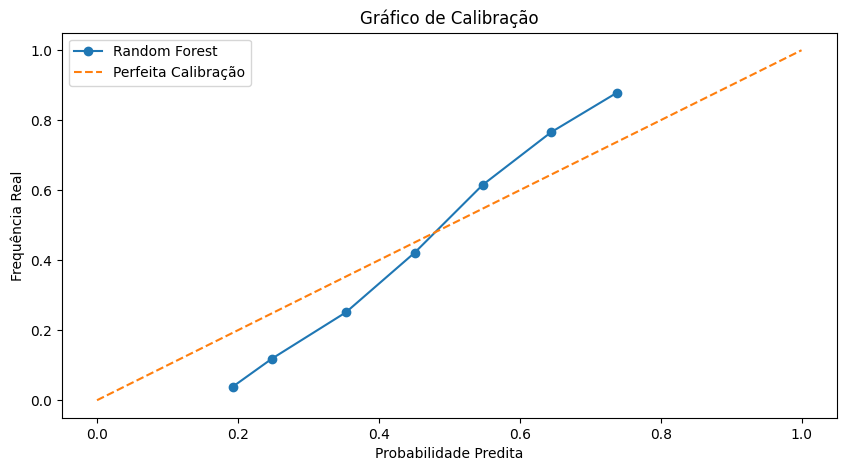

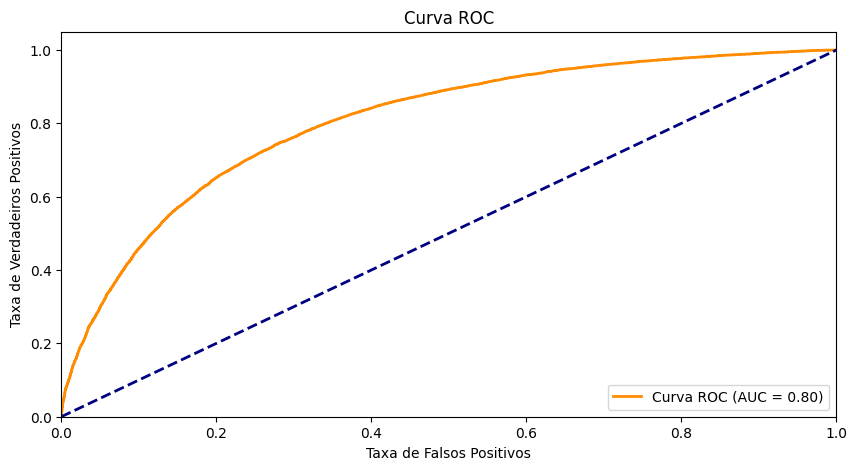

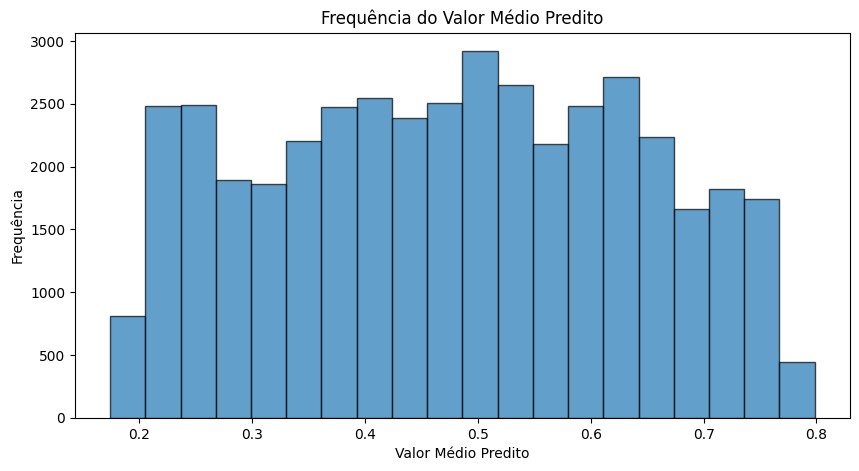

In [56]:
# Plotar curvas de calibração e curva ROC

plot_calibration_and_roc_curve(rf_final, model_name="Random Forest")

## XGBoost

In [72]:
import xgboost as xgb
import time
from datetime import timedelta

start_time = time.time()

random_state = 42

# Definição do modelo
xgboost_model = xgb.XGBClassifier(random_state=random_state)

# Definição dos intervalos de hiperparâmetros para busca dos melhores 
param_dist = {
    'max_depth': stats.randint(5, 10),
    'eta': stats.uniform(0.01, 0.02),
    'n_estimators':stats.randint(800, 1000),
}

# Realizar busca aleatória dos melhores hiperparâmetros
random_search_xgb = RandomizedSearchCV(xgboost_model, param_distributions=param_dist, n_iter=10, cv=5, scoring='roc_auc', n_jobs=-1, random_state=random_state)

# Treinar modelo com cross validation e várias iterações buscando os melhores hiperparâmetros
random_search_xgb.fit(X_train, y_train.values.ravel())

# Imprimir resultados
print("Best set of hyperparameters: ", random_search_xgb.best_params_)
print("Best score: ", random_search_xgb.best_score_)

# Calcular tempo
end_time = time.time()
elapsed_time = end_time - start_time
formatted_time = str(timedelta(seconds=elapsed_time))
print(f"Time taken: {formatted_time}")

Best set of hyperparameters:  {'eta': 0.014246782213565522, 'max_depth': 8, 'n_estimators': 820}
Best score:  0.8339317554911714
Time taken: 0:02:43.703758


In [73]:
# Selecionar melhor modelo
xgb_model = random_search_xgb.best_estimator_
xgb_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eta=0.014246782213565522,
              eval_metric=None, feature_types=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=820, n_jobs=None,
              num_parallel_tree=None, ...)

In [74]:
# Avaliar performance no dataset de validação
eval(xgb_model, model_name="XGBoost", dataset_name="Validation", X=X_val, y=y_val)

XGBoost Model - Validation dataset
Accuracy: 0.7530
Precision: 0.7364
Recall: 0.7499
AUC: 0.8324
              precision    recall  f1-score   support

           0       0.77      0.76      0.76     20036
           1       0.74      0.75      0.74     18222

    accuracy                           0.75     38258
   macro avg       0.75      0.75      0.75     38258
weighted avg       0.75      0.75      0.75     38258



In [75]:
# Após algumas iterações, treinar modelo final para avaliação no teste usando dados disponíveis nos datasets de treino e validação. 

from xgboost import XGBClassifier

# Definição do modelo
xgb_final = XGBClassifier(**random_search_xgb.best_params_)

# Treinar com dados de treino e validação
xgb_final.fit(
    X = pd.concat([X_train, X_val]),
    y = pd.concat([y_train, y_val]).values.ravel()
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eta=0.014246782213565522,
              eval_metric=None, feature_types=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=820, n_jobs=None,
              num_parallel_tree=None, ...)

In [76]:
# Avaliar performance no dataset de teste
eval(xgb_final, model_name="XGBoost", dataset_name="Test", X=X_test, y=y_test)

XGBoost Model - Test dataset
Accuracy: 0.7518
Precision: 0.7364
Recall: 0.7499
AUC: 0.8313
              precision    recall  f1-score   support

           0       0.77      0.75      0.76     22164
           1       0.74      0.75      0.74     20345

    accuracy                           0.75     42509
   macro avg       0.75      0.75      0.75     42509
weighted avg       0.75      0.75      0.75     42509



In [79]:
# Salvar modelo final no disco
import joblib

joblib.dump(xgb_final, Path('trained_models','xgboost_model.pkl'))

['trained_models\\xgboost_model.pkl']

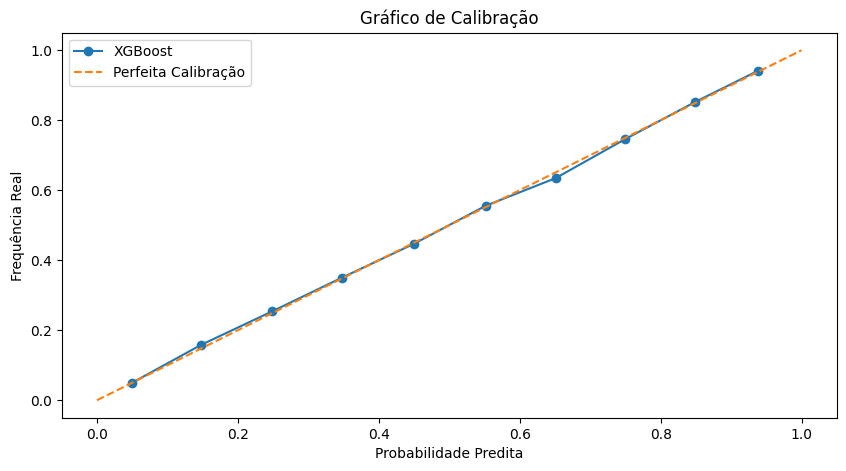

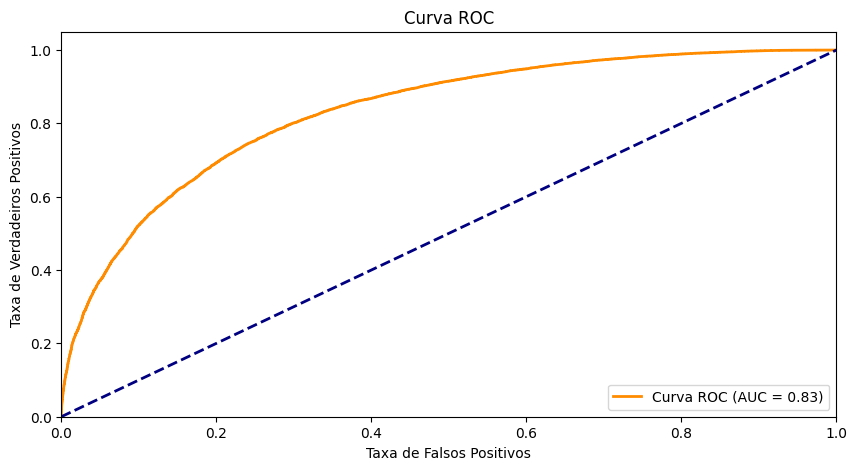

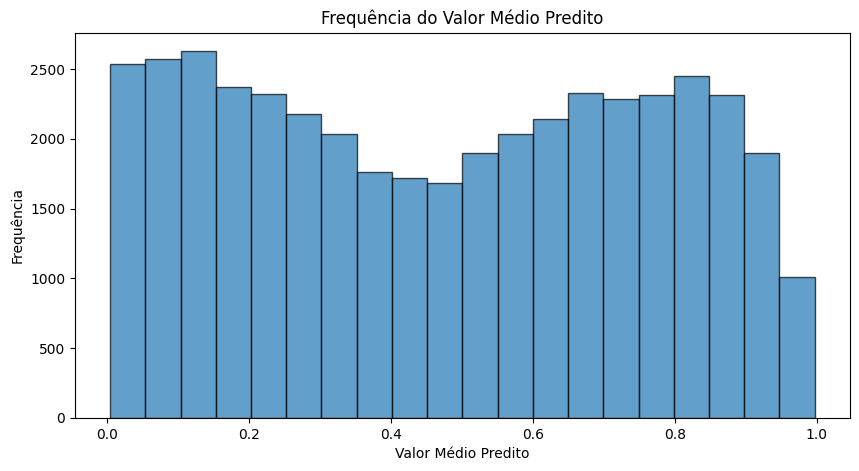

In [80]:
# Plotar curvas de calibração e curva ROC

plot_calibration_and_roc_curve(xgb_final, model_name="XGBoost")

## LightGBM

In [269]:
import lightgbm as lgb
from datetime import timedelta

start_time = time.time()

# Definição do modelo
lgm_model = lgb.LGBMClassifier(verbose=-1, random_state=42)

# Hiperparâmetros
rs_params_lgbm = {
        'boosting_type': ['gbdt', 'dart', 'rf'],
        'bagging_fraction': stats.uniform(0.5, 0.8),
        'bagging_frequency': stats.randint(5, 8),
        'feature_fraction': stats.uniform(0.5, 0.9),
        'max_depth': stats.randint(5, 15),
        'min_data_in_leaf': stats.randint(30, 150),
        'num_leaves': stats.randint(1400, 2000),
        'learning_rate': stats.uniform(0.001, 0.1),
}

rs_cv_lgbm = RandomizedSearchCV(lgm_model, param_distributions=rs_params_lgbm, cv=3, n_iter=50)

# Treinar modelo com cross validation e várias iterações buscando os melhores hiperparâmetros
rs_cv_lgbm.fit(X_train, y_train)

# Imprimir resultados
print("Best set of hyperparameters: ", rs_cv_lgbm.best_params_)
print("Best score: ", rs_cv_lgbm.best_score_)

# Calcular tempo
end_time = time.time()
elapsed_time = end_time - start_time
formatted_time = str(timedelta(seconds=elapsed_time))
print(f"Time taken: {formatted_time}")


Best set of hyperparameters:  {'bagging_fraction': 0.5507829510487401, 'bagging_frequency': 6, 'boosting_type': 'gbdt', 'feature_fraction': 0.6245779471721158, 'learning_rate': 0.09612615199813647, 'max_depth': 9, 'min_data_in_leaf': 141, 'num_leaves': 1844}
Best score:  0.7544754894407705
Time taken: 0:02:53.938674


In [270]:
# Selecionar melhor modelo
lgbm_model = rs_cv_lgbm.best_estimator_
lgbm_model

LGBMClassifier(bagging_fraction=0.5507829510487401, bagging_frequency=6,
               feature_fraction=0.6245779471721158,
               learning_rate=0.09612615199813647, max_depth=9,
               min_data_in_leaf=141, num_leaves=1844, random_state=42,
               verbose=-1)

In [271]:
# Avaliar performance no dataset de validação
eval(lgbm_model, model_name="LightGBM", dataset_name="Validation", X=X_val, y=y_val)

LightGBM Model - Validation dataset
Accuracy: 0.7560
Precision: 0.7396
Recall: 0.7527
AUC: 0.8336
              precision    recall  f1-score   support

           0       0.77      0.76      0.77     20036
           1       0.74      0.75      0.75     18222

    accuracy                           0.76     38258
   macro avg       0.76      0.76      0.76     38258
weighted avg       0.76      0.76      0.76     38258



In [272]:
# Após algumas iterações, treinar modelo final para avaliação no teste usando dados disponíveis nos datasets de treino e validação. 

# Definição do modelo
lgbm_final = lgb.LGBMClassifier(verbose=-1, random_state=42, **rs_cv_lgbm.best_params_)

# Treinar com dados de treino e validação
lgbm_final.fit(
    X = pd.concat([X_train, X_val]),
    y = pd.concat([y_train, y_val]).values.ravel()
)

LGBMClassifier(bagging_fraction=0.5507829510487401, bagging_frequency=6,
               feature_fraction=0.6245779471721158,
               learning_rate=0.09612615199813647, max_depth=9,
               min_data_in_leaf=141, num_leaves=1844, random_state=42,
               verbose=-1)

In [273]:
# Avaliar performance no dataset de teste
eval(lgbm_final, model_name="LightGBM", dataset_name="Test", X=X_test, y=y_test)

LightGBM Model - Test dataset
Accuracy: 0.7521
Precision: 0.7368
Recall: 0.7500
AUC: 0.8315
              precision    recall  f1-score   support

           0       0.77      0.75      0.76     22164
           1       0.74      0.75      0.74     20345

    accuracy                           0.75     42509
   macro avg       0.75      0.75      0.75     42509
weighted avg       0.75      0.75      0.75     42509



In [278]:
# Salvar modelo final no disco
import joblib

joblib.dump(lgbm_final, Path('trained_models','light_gbm_model.pkl'))

['trained_models\\light_gbm_model.pkl']

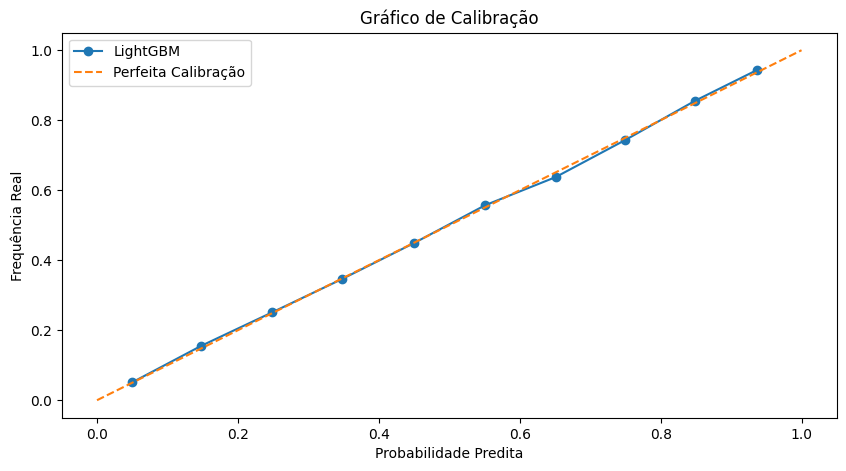

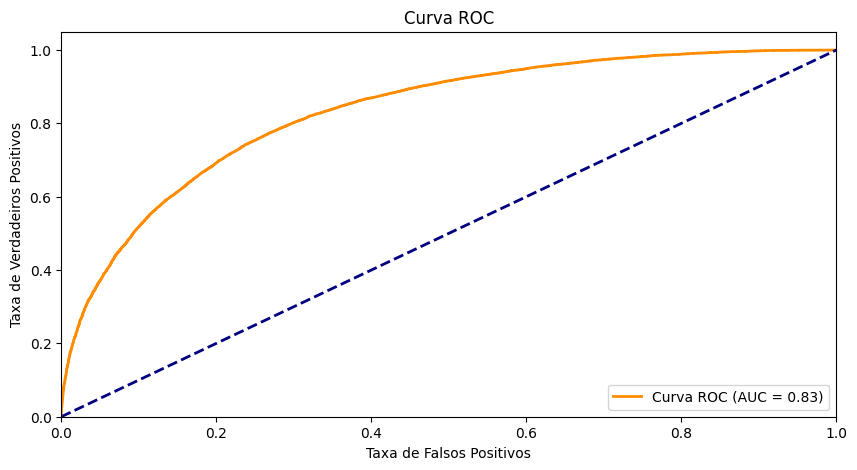

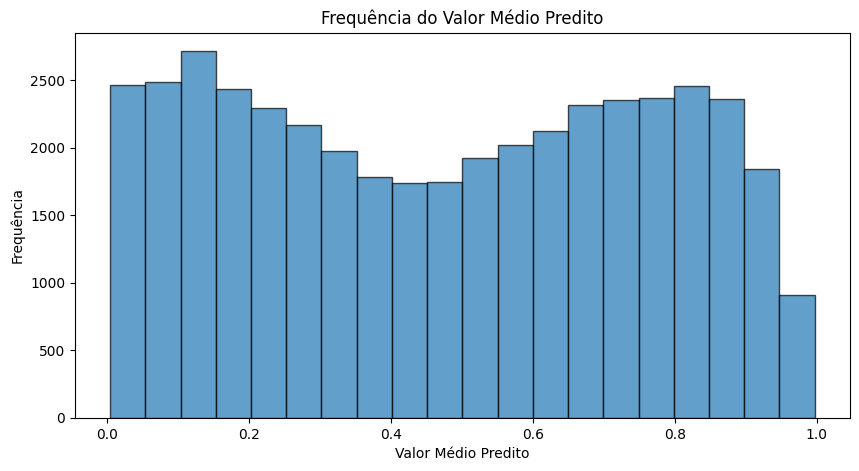

In [279]:
# Plotar curvas de calibração e curva ROC

plot_calibration_and_roc_curve(lgbm_final, model_name="LightGBM")

## CatBoost

In [3]:
from catboost import CatBoostClassifier
from datetime import timedelta
import time

start_time = time.time()

# Definição do modelo
catboost_rs = CatBoostClassifier(eval_metric='Logloss', silent=True, random_seed=42, use_best_model=False, task_type='GPU')

# Definição dos intervalos de hiperparâmetros para busca dos melhores 
param_dist = {
        "depth": stats.randint(5, 16),
        "iterations": stats.randint(250, 350),
        "learning_rate": stats.uniform(0.01, 0.05),
        "l2_leaf_reg": stats.randint(60, 90),
        "border_count": stats.randint(30, 60)
        }


# Realizar busca aleatória dos melhores hiperparâmetros
rs_cv_catboost = RandomizedSearchCV(catboost_rs, n_iter=10, cv=5, param_distributions=param_dist, n_jobs=1)

# Treinar modelo com cross validation e várias iterações buscando os melhores hiperparâmetros
rs_cv_catboost.fit(X_train, y_train)

# Imprimir resultados
print("Best set of hyperparameters: ", rs_cv_catboost.best_params_)
print("Best score: ", rs_cv_catboost.best_score_)

# Calcular tempo
end_time = time.time()
elapsed_time = end_time - start_time
formatted_time = str(timedelta(seconds=elapsed_time))
print(f"Time taken: {formatted_time}")

Best set of hyperparameters:  {'border_count': 57, 'depth': 12, 'iterations': 328, 'l2_leaf_reg': 61, 'learning_rate': 0.04433986108055431}
Best score:  0.7548472351301115
Time taken: 0:19:32.761863


In [4]:
# Selecionar melhor modelo
catboost_model = rs_cv_catboost.best_estimator_
catboost_model

In [8]:
# Avaliar performance no dataset de validação
eval(catboost_model, model_name="CatBoost", dataset_name="Validation", X=X_val, y=y_val)

CatBoost Model - Validation dataset
Accuracy: 0.7554
Precision: 0.7392
Recall: 0.7515
AUC: 0.8333
              precision    recall  f1-score   support

           0       0.77      0.76      0.76     20036
           1       0.74      0.75      0.75     18222

    accuracy                           0.76     38258
   macro avg       0.75      0.76      0.75     38258
weighted avg       0.76      0.76      0.76     38258



In [9]:
# Após algumas iterações, treinar modelo final para avaliação no teste usando dados disponíveis nos datasets de treino e validação. 

# Definição do modelo
catboost_final = CatBoostClassifier(eval_metric='Logloss', silent=True, random_seed=42, use_best_model=False, task_type='GPU', **rs_cv_catboost.best_params_)

# Treinar com dados de treino e validação
catboost_final.fit(
    X = pd.concat([X_train, X_val]),
    y = pd.concat([y_train, y_val]).values.ravel()
)

In [10]:
# Avaliar performance no dataset de teste
eval(catboost_final, model_name="CatBoost", dataset_name="Test", X=X_test, y=y_test)

CatBoost Model - Test dataset
Accuracy: 0.7520
Precision: 0.7372
Recall: 0.7487
AUC: 0.8320
              precision    recall  f1-score   support

           0       0.77      0.76      0.76     22164
           1       0.74      0.75      0.74     20345

    accuracy                           0.75     42509
   macro avg       0.75      0.75      0.75     42509
weighted avg       0.75      0.75      0.75     42509



In [11]:
# Salvar modelo final no disco
import joblib

joblib.dump(catboost_final, Path('trained_models','catboost_model.pkl'))

['trained_models\\catboost_model.pkl']

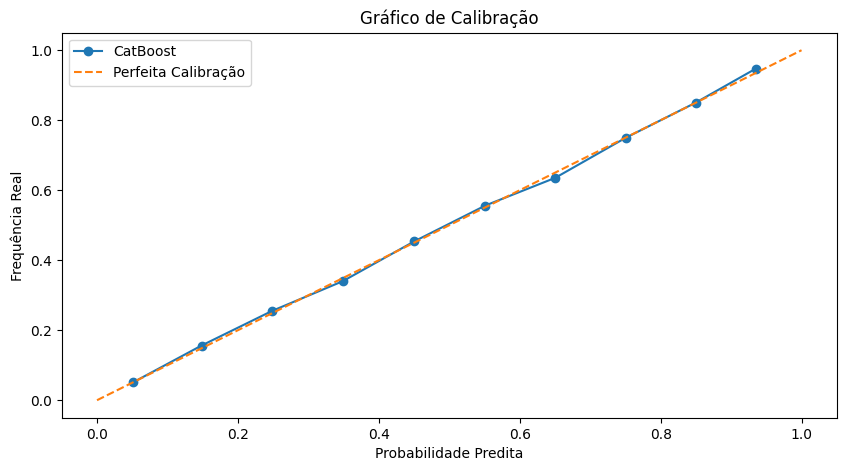

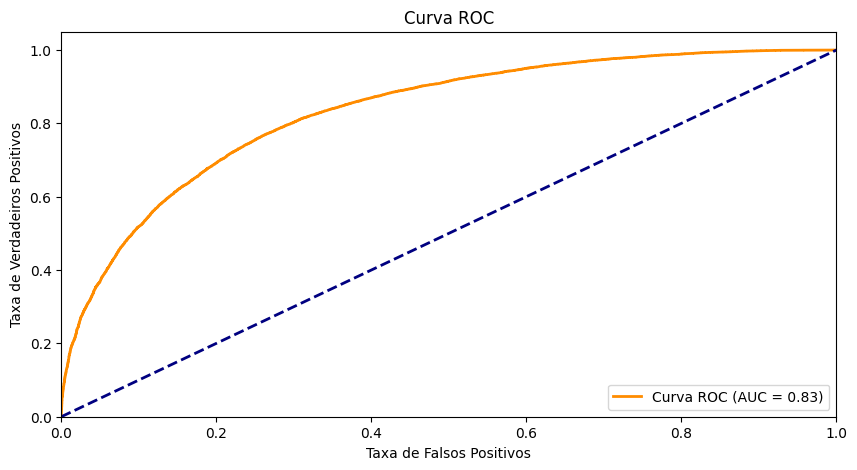

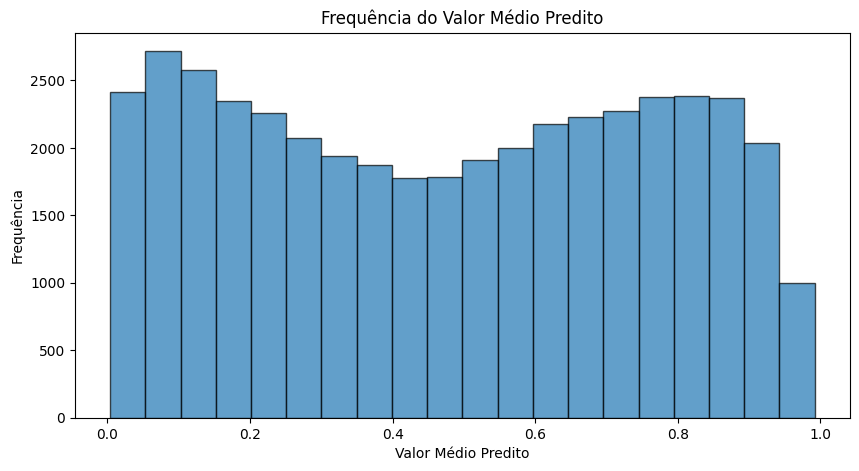

In [12]:
# Plotar curvas de calibração e curva ROC

plot_calibration_and_roc_curve(catboost_final, model_name="CatBoost")

## Multilayer Perceptron

In [14]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from pathlib import Path
import time, copy
import matplotlib.pyplot as plt
import numpy as np


# Carregar dados
X_train = pd.read_csv(Path('cleaned_data','X_train.csv'), index_col=0)
X_val = pd.read_csv(Path('cleaned_data','X_val.csv'), index_col=0)
X_test = pd.read_csv(Path('cleaned_data','X_test.csv'), index_col=0)

y_train = pd.read_csv(Path('cleaned_data','y_train.csv'), index_col=0)
y_val = pd.read_csv(Path('cleaned_data','y_val.csv'), index_col=0)
y_test = pd.read_csv(Path('cleaned_data','y_test.csv'), index_col=0)

# Configurar hardware
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [27]:
# Definir classe do dataset

class MimicIvDataset(Dataset):
    """MIMIC IV dataset."""

    def __init__(self, csv_file_X=None, csv_file_y=None, X=None, y=None):
        """
        Arguments:
            csv_file (string): Path to the csv file with annotations.
        """
        if csv_file_X and csv_file_y:
            self.mimic_df_X = pd.read_csv(Path(csv_file_X), index_col=0)
            self.mimic_df_y = pd.read_csv(Path(csv_file_y), index_col=0)
        else:
            self.mimic_df_X = X
            self.mimic_df_y = y

    def __len__(self):
        return len(self.mimic_df_X)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
            
        inputs = torch.tensor(self.mimic_df_X.iloc[idx], dtype=torch.float64)
        labels = torch.tensor(self.mimic_df_y.iloc[idx], dtype=torch.float64)

        return inputs, labels

# Carregar datasets
train_dataset = MimicIvDataset(csv_file_X="cleaned_data/X_train.csv", csv_file_y="cleaned_data/y_train.csv")
val_dataset = MimicIvDataset(csv_file_X="cleaned_data/X_val.csv", csv_file_y="cleaned_data/y_val.csv")
test_dataset = MimicIvDataset(csv_file_X="cleaned_data/X_test.csv", csv_file_y="cleaned_data/y_test.csv")


In [16]:
# Criar dataloaders

batch_size = 100

dataloaders = {'train': DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
               'val': DataLoader(val_dataset, batch_size=batch_size, shuffle=True),
               'test': DataLoader(test_dataset, batch_size=batch_size, shuffle=True)}

dataset_sizes = {'train': len(train_dataset),
                 'val': len(val_dataset),
                 'test': len(test_dataset)}
print(f'dataset_sizes = {dataset_sizes}')

dataset_sizes = {'train': 344320, 'val': 38258, 'test': 42509}


In [19]:
import torch
import torch.nn as nn

# Definir hiperparâmetros
input_size = 67
hidden_size1 = 128
hidden_size2 = 128
hidden_size3 = 128
num_classes = 1
dropout_rate = 0.5  
learning_rate = 0.0001
num_epochs = 40

# Definir modelo
class MimicAdmissionClassifier(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, hidden_size3, num_classes, dropout_rate, activation_fn=nn.ReLU, dtype=torch.float32):
        """
        Args:
            input_size (int): tamanho do input (número de features).
            hidden_size1 (int): Tamanho da primeira camada.
            hidden_size2 (int): Tamanho da segunda camada.
            hidden_size3 (int): Tamanho da terceira camada.
            num_classes (int): número de classes.
            dropout_rate (float): fração de dropout para regularização.
            activation_fn (torch.nn.Module): função de ativação.
            dtype (torch.dtype): tipo de dados.
        """
        super(MimicAdmissionClassifier, self).__init__()
        self.dropout = nn.Dropout(dropout_rate) 

        # MLP
        self.mlp = nn.Sequential(
            nn.Linear(input_size, hidden_size1, dtype=dtype),
            activation_fn(),
            self.dropout,
            nn.Linear(hidden_size1, hidden_size2, dtype=dtype),
            activation_fn(),
            self.dropout,
            nn.Linear(hidden_size2, hidden_size3, dtype=dtype),
            activation_fn(),
            self.dropout,
            nn.Linear(hidden_size3, num_classes, dtype=dtype),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.mlp(x)


In [20]:
# Instanciar modelo
mimic_admission_classifier = MimicAdmissionClassifier(
    input_size=input_size,
    hidden_size1=hidden_size1,
    hidden_size2=hidden_size2,
    hidden_size3=hidden_size3,
    num_classes=num_classes,
    dropout_rate=dropout_rate,
    activation_fn=nn.ReLU,  
    dtype=torch.float64  
).to(device)

# Imprimir arquitetura do modelo
print(mimic_admission_classifier)


MimicAdmissionClassifier(
  (dropout): Dropout(p=0.5, inplace=False)
  (mlp): Sequential(
    (0): Linear(in_features=67, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.5, inplace=False)
    (9): Linear(in_features=128, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


In [22]:
# Definir função de treinamento do modelo
from torchmetrics.classification import BinaryF1Score, BinaryAccuracy, BinaryAUROC

def train_classification_model(model, dataloaders, dataset_sizes, criterion, optimizer, scheduler, num_epochs=5, threshold=0.5, eval=True):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict()) # keep the best weights stored separately
    best_acc = 0.0
    best_epoch = 0

    # Métricas de avaliação
    f1 = BinaryF1Score(threshold=threshold).to(device)
    acc = BinaryAccuracy(threshold=threshold).to(device)
    auc = BinaryAUROC().to(device)

    # Fases do treinamento por época
    phases = ['train', 'val', 'test']
    
    # Definir variáveis para acompanhar evolução do treinamento
    training_curves = {}
    for phase in phases:
        training_curves[phase+'_loss'] = []
        training_curves[phase+'_acc'] = []

    # Iniciar loop de treinamento
    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in phases:
            if phase == 'train':
                model.train() 
            else:
                model.eval() 

            running_loss = 0.0
            since_phase = time.time()
                        
            
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zerar gradientes
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    # Rodar backpropagation e atualizar pesos se for dataset de treino
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Computar métricass
                running_loss += loss.item() * inputs.size(0)
                acc(outputs.detach(), labels.detach())
                            
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = acc.compute()
            training_curves[phase+'_loss'].append(epoch_loss)
            training_curves[phase+'_acc'].append(epoch_acc)       

            phase_time_elapsed = time.time() - since_phase

            print(f'{phase:5} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} Time elapsed: {phase_time_elapsed // 60:.0f}m {phase_time_elapsed % 60:.0f}s')

            # Copiar modelo se for o melhor até o momento em comparação com o dataset de validação
            if phase == 'val' and epoch_acc > best_acc:
              best_epoch = epoch
              best_acc = epoch_acc
              best_model_wts = copy.deepcopy(model.state_dict())

            # Resetar métricas para a próxima época
            acc.reset()

    time_elapsed = time.time() - since
    print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f} at epoch {best_epoch}')

    # Avaliar o modelo final com outras métricas
    print('\nEvaluating trained model')
    with torch.set_grad_enabled(False):
        model.eval()
        if eval:
            for phase in phases:
                if phase=='train': continue

                running_loss = 0.0
                since_phase = time.time()
                            
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    running_loss += loss.item() * inputs.size(0)
                    acc(outputs.detach(), labels.detach())
                    f1(outputs.detach(), labels.detach())
                    auc(outputs.detach(), labels.detach())

                # Computar métricas de avaliação finais
                final_loss = running_loss / dataset_sizes[phase]
                final_acc = acc.compute()
                final_f1 = f1.compute()
                final_auc = auc.compute()

                phase_time_elapsed = time.time() - since_phase

                print(f'{phase:5} Loss: {final_loss:.4f} Acc: {final_acc:.4f} F1: {final_f1:.4f} AUC: {final_auc:.4f} Time elapsed: {phase_time_elapsed // 60:.0f}m {phase_time_elapsed % 60:.0f}s')

                # Resetar métricas
                f1.reset()
                acc.reset()
                auc.reset()


    # Carregar o melhor modelo e retornar junto com dados de treino
    model.load_state_dict(best_model_wts)
    
    return model, training_curves


In [23]:
# Treinamento do modelo
# loss and optimizer
criterion = nn.BCELoss() 
optimizer = torch.optim.Adam(mimic_admission_classifier.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

# Executar treinamento
mimic_admission_classifier, training_curves = train_classification_model(mimic_admission_classifier, dataloaders, dataset_sizes, criterion, optimizer, scheduler, num_epochs=num_epochs)

# Salvar modelo final
torch.save(mimic_admission_classifier.state_dict(), Path("trained_models","mimic_admission_classifier_final.pt"))



Epoch 1/40
----------


C:\Users\Vinicius\AppData\Local\Temp\ipykernel_25344\3226686080.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  inputs = torch.tensor(self.mimic_df_X.iloc[idx], dtype=torch.float64)
C:\Users\Vinicius\AppData\Local\Temp\ipykernel_25344\3226686080.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  labels = torch.tensor(self.mimic_df_y.iloc[idx], dtype=torch.float64)


train Loss: 0.5480 Acc: 0.7259 Time elapsed: 0m 40s
val   Loss: 0.5166 Acc: 0.7455 Time elapsed: 0m 4s
test  Loss: 0.5194 Acc: 0.7421 Time elapsed: 0m 4s

Epoch 2/40
----------
train Loss: 0.5252 Acc: 0.7413 Time elapsed: 0m 40s
val   Loss: 0.5131 Acc: 0.7478 Time elapsed: 0m 4s
test  Loss: 0.5161 Acc: 0.7442 Time elapsed: 0m 4s

Epoch 3/40
----------
train Loss: 0.5209 Acc: 0.7446 Time elapsed: 0m 40s
val   Loss: 0.5108 Acc: 0.7491 Time elapsed: 0m 4s
test  Loss: 0.5137 Acc: 0.7458 Time elapsed: 0m 4s

Epoch 4/40
----------
train Loss: 0.5179 Acc: 0.7457 Time elapsed: 0m 40s
val   Loss: 0.5091 Acc: 0.7494 Time elapsed: 0m 4s
test  Loss: 0.5122 Acc: 0.7465 Time elapsed: 0m 4s

Epoch 5/40
----------
train Loss: 0.5169 Acc: 0.7464 Time elapsed: 0m 41s
val   Loss: 0.5082 Acc: 0.7503 Time elapsed: 0m 4s
test  Loss: 0.5114 Acc: 0.7471 Time elapsed: 0m 4s

Epoch 6/40
----------
train Loss: 0.5152 Acc: 0.7475 Time elapsed: 0m 41s
val   Loss: 0.5073 Acc: 0.7504 Time elapsed: 0m 4s
test  Loss: 

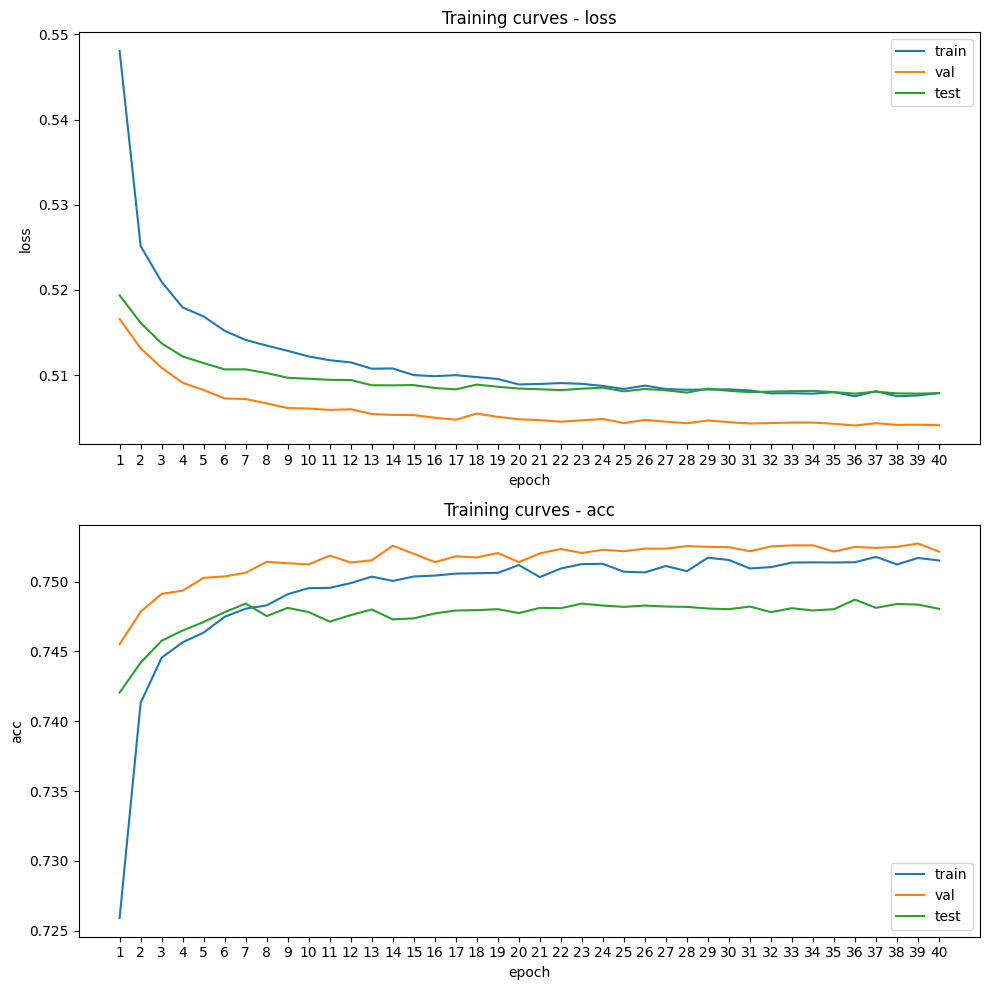

In [26]:

import sklearn.metrics as metrics

# Utility functions for plotting your results!
def plot_training_curves(training_curves, 
                         phases=['train', 'val', 'test'],
                         metrics=['loss','acc']):
    epochs = list(range(1, len(training_curves['train_loss'])+1))
    fig, axs = plt.subplots(len(metrics), 1, figsize=(10, 10), tight_layout=True)
    for idx, metric in enumerate(metrics):
        ax = axs[idx]     
        ax.set_title(f'Training curves - {metric}')
        ax.set_ylabel(metric)
        ax.xaxis.set_ticks(np.arange(1, len(epochs)+1, 1))
        for phase in phases:
            key = phase+'_'+metric
            if key in training_curves:
                if metric == 'acc' or metric == 'f1' or metric == 'auc':
                    ax.plot(epochs, [item.detach().cpu() for item in training_curves[key]])
                else:
                    ax.plot(epochs, training_curves[key])
        ax.set_xlabel('epoch')
        ax.legend(labels=phases)

def classify_predictions(model, device, dataloader):
    model.eval() 
    all_labels = torch.tensor([]).to(device)
    all_scores = torch.tensor([]).to(device)
    all_preds = torch.tensor([]).to(device)
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        preds = torch.where(outputs < 0.5, 0, 1).view(-1)
        scores = outputs.view(-1)
        all_labels = torch.cat((all_labels, labels), 0)
        all_scores = torch.cat((all_scores, scores), 0)
        all_preds = torch.cat((all_preds, preds), 0).view(-1)
    return all_preds.detach().cpu(), all_labels.detach().cpu(), all_scores.detach().cpu()

def plot_cm(model, device, dataloaders, phase='test'):
    class_labels = [0, 1]
    preds, labels, scores = classify_predictions(model, device, dataloaders[phase])
    
    cm = metrics.confusion_matrix(labels, preds)
    disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    ax = disp.plot().ax_
    ax.set_title('Confusion Matrix -- counts')


plot_training_curves(training_curves, phases=['train', 'val', 'test'])
plt.show()


In [29]:
# Após algumas iterações, treinar modelo final para avaliação no teste usando dados disponíveis nos datasets de treino e validação. 

# Concatenar dataset de treino e validação
train_val_dataset = MimicIvDataset(X=pd.concat([X_train, X_val]), y=pd.concat([y_train, y_val]))

# Criar dataloaders
batch_size = 100

final_dataloaders = {'train': DataLoader(train_val_dataset, batch_size=batch_size, shuffle=True),
                       'test': DataLoader(test_dataset, batch_size=batch_size, shuffle=True)}

final_dataset_sizes = {'train': len(train_val_dataset),
                         'test': len(test_dataset)}
print(f'dataset_sizes = {final_dataset_sizes}')

dataset_sizes = {'train': 382578, 'test': 42509}


In [30]:
# Instanciar modelo
final_mimic_admission_classifier = MimicAdmissionClassifier(
    input_size=input_size,
    hidden_size1=hidden_size1,
    hidden_size2=hidden_size2,
    hidden_size3=hidden_size3,
    num_classes=num_classes,
    dropout_rate=dropout_rate,
    activation_fn=nn.ReLU,  
    dtype=torch.float64  
).to(device)

# Imprimir arquitetura do modelo
print(final_mimic_admission_classifier)

MimicAdmissionClassifier(
  (dropout): Dropout(p=0.5, inplace=False)
  (mlp): Sequential(
    (0): Linear(in_features=67, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.5, inplace=False)
    (9): Linear(in_features=128, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


In [31]:
# Definir função de treinamento do modelo
from torchmetrics.classification import BinaryF1Score, BinaryAccuracy, BinaryAUROC

def train_classification_model(model, dataloaders, dataset_sizes, criterion, optimizer, scheduler, num_epochs=5, threshold=0.5, eval=True):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict()) # keep the best weights stored separately
    best_acc = 0.0
    best_epoch = 0

    # Métricas de avaliação
    f1 = BinaryF1Score(threshold=threshold).to(device)
    acc = BinaryAccuracy(threshold=threshold).to(device)
    auc = BinaryAUROC().to(device)

    # Fases do treinamento por época
    phases = ['train']
    
    # Definir variáveis para acompanhar evolução do treinamento
    training_curves = {}
    for phase in phases:
        training_curves[phase+'_loss'] = []
        training_curves[phase+'_acc'] = []

    # Iniciar loop de treinamento
    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in phases:
            if phase == 'train':
                model.train() 
            else:
                model.eval() 

            running_loss = 0.0
            since_phase = time.time()
                        
            
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zerar gradientes
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    # Rodar backpropagation e atualizar pesos se for dataset de treino
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Computar métricass
                running_loss += loss.item() * inputs.size(0)
                acc(outputs.detach(), labels.detach())
                            
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = acc.compute()
            training_curves[phase+'_loss'].append(epoch_loss)
            training_curves[phase+'_acc'].append(epoch_acc)       

            phase_time_elapsed = time.time() - since_phase

            print(f'{phase:5} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} Time elapsed: {phase_time_elapsed // 60:.0f}m {phase_time_elapsed % 60:.0f}s')

            if epoch_acc > best_acc:
              best_epoch = epoch
              best_acc = epoch_acc
              best_model_wts = copy.deepcopy(model.state_dict())

            # Resetar métricas para a próxima época
            acc.reset()

    time_elapsed = time.time() - since
    print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')

    # Avaliar o modelo final com outras métricas
    print('\nEvaluating trained model')
    with torch.set_grad_enabled(False):
        model.eval()
        if eval:
            phase = 'test'
            running_loss = 0.0
            since_phase = time.time()
                        
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * inputs.size(0)
                acc(outputs.detach(), labels.detach())
                f1(outputs.detach(), labels.detach())
                auc(outputs.detach(), labels.detach())

            # Computar métricas de avaliação finais
            final_loss = running_loss / dataset_sizes[phase]
            final_acc = acc.compute()
            final_f1 = f1.compute()
            final_auc = auc.compute()

            phase_time_elapsed = time.time() - since_phase

            print(f'{phase:5} Loss: {final_loss:.4f} Acc: {final_acc:.4f} F1: {final_f1:.4f} AUC: {final_auc:.4f} Time elapsed: {phase_time_elapsed // 60:.0f}m {phase_time_elapsed % 60:.0f}s')

            # Resetar métricas
            f1.reset()
            acc.reset()
            auc.reset()

    # Carregar o melhor modelo e retornar junto com dados de treino
    model.load_state_dict(best_model_wts)
    
    return model, training_curves


In [33]:
# Definição do modelo
# loss and optimizer
criterion = nn.BCELoss() 
optimizer = torch.optim.Adam(final_mimic_admission_classifier.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

# Executar treinamento
final_mimic_admission_classifier, training_curves = train_classification_model(final_mimic_admission_classifier, final_dataloaders, final_dataset_sizes, criterion, optimizer, scheduler, num_epochs=num_epochs)

# Salvar modelo final
torch.save(final_mimic_admission_classifier.state_dict(), Path("trained_models","mimic_admission_classifier_final.pt"))


Epoch 1/40
----------


C:\Users\Vinicius\AppData\Local\Temp\ipykernel_25344\2067220621.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  inputs = torch.tensor(self.mimic_df_X.iloc[idx], dtype=torch.float64)
C:\Users\Vinicius\AppData\Local\Temp\ipykernel_25344\2067220621.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  labels = torch.tensor(self.mimic_df_y.iloc[idx], dtype=torch.float64)


train Loss: 0.5453 Acc: 0.7273 Time elapsed: 0m 44s

Epoch 2/40
----------
train Loss: 0.5251 Acc: 0.7414 Time elapsed: 0m 42s

Epoch 3/40
----------
train Loss: 0.5210 Acc: 0.7439 Time elapsed: 0m 43s

Epoch 4/40
----------
train Loss: 0.5185 Acc: 0.7459 Time elapsed: 0m 44s

Epoch 5/40
----------
train Loss: 0.5164 Acc: 0.7463 Time elapsed: 0m 45s

Epoch 6/40
----------
train Loss: 0.5152 Acc: 0.7470 Time elapsed: 0m 45s

Epoch 7/40
----------
train Loss: 0.5142 Acc: 0.7478 Time elapsed: 0m 44s

Epoch 8/40
----------
train Loss: 0.5135 Acc: 0.7483 Time elapsed: 0m 44s

Epoch 9/40
----------
train Loss: 0.5127 Acc: 0.7482 Time elapsed: 0m 45s

Epoch 10/40
----------
train Loss: 0.5121 Acc: 0.7493 Time elapsed: 0m 45s

Epoch 11/40
----------
train Loss: 0.5116 Acc: 0.7494 Time elapsed: 0m 44s

Epoch 12/40
----------
train Loss: 0.5113 Acc: 0.7497 Time elapsed: 0m 44s

Epoch 13/40
----------
train Loss: 0.5106 Acc: 0.7499 Time elapsed: 0m 44s

Epoch 14/40
----------
train Loss: 0.5105 A

In [60]:
# Avaliar performance do modelo no dataset de teste

final_mimic_admission_classifier.eval()

threshold = 0.5
prob_pos = []
y_pred = []
for inputs, labels in test_dataset:
    inputs = inputs.to(device)
    labels = labels.to(device)

    outputs = final_mimic_admission_classifier(inputs)
    prob_pos.append(outputs.item())
    y_pred.append(outputs.item()>threshold)

C:\Users\Vinicius\AppData\Local\Temp\ipykernel_25344\2067220621.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  inputs = torch.tensor(self.mimic_df_X.iloc[idx], dtype=torch.float64)
C:\Users\Vinicius\AppData\Local\Temp\ipykernel_25344\2067220621.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  labels = torch.tensor(self.mimic_df_y.iloc[idx], dtype=torch.float64)


In [63]:
print(f'Multilayer Perceptron Model - Test dataset')
print("Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred)))
print("Precision: {:.4f}".format(precision_score(y_test, y_pred)))
print("Recall: {:.4f}".format(recall_score(y_test, y_pred)))
print("AUC: {:.4f}".format(roc_auc_score(y_test, prob_pos)))
print(classification_report(y_test, y_pred))

Multilayer Perceptron Model - Test dataset
Accuracy: 0.7481
Precision: 0.7399
Recall: 0.7305
AUC: 0.8286
              precision    recall  f1-score   support

           0       0.76      0.76      0.76     22164
           1       0.74      0.73      0.74     20345

    accuracy                           0.75     42509
   macro avg       0.75      0.75      0.75     42509
weighted avg       0.75      0.75      0.75     42509



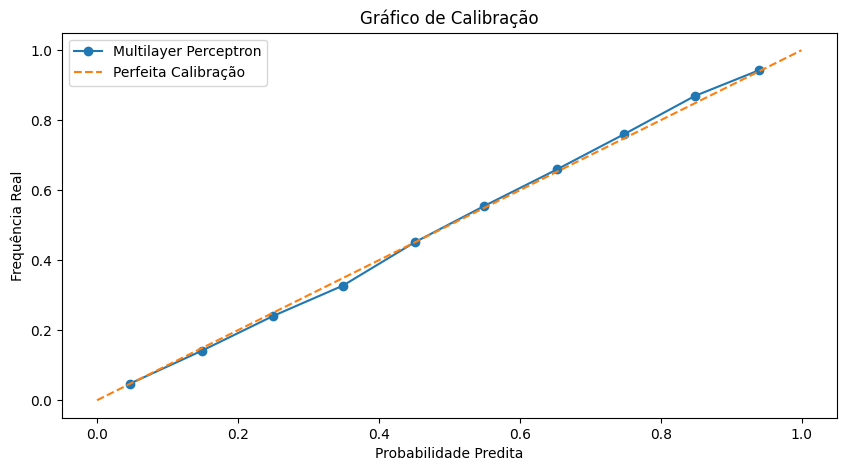

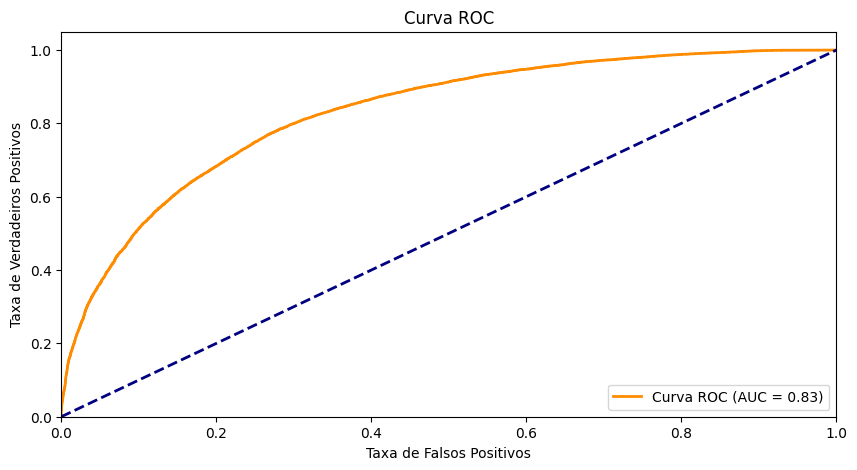

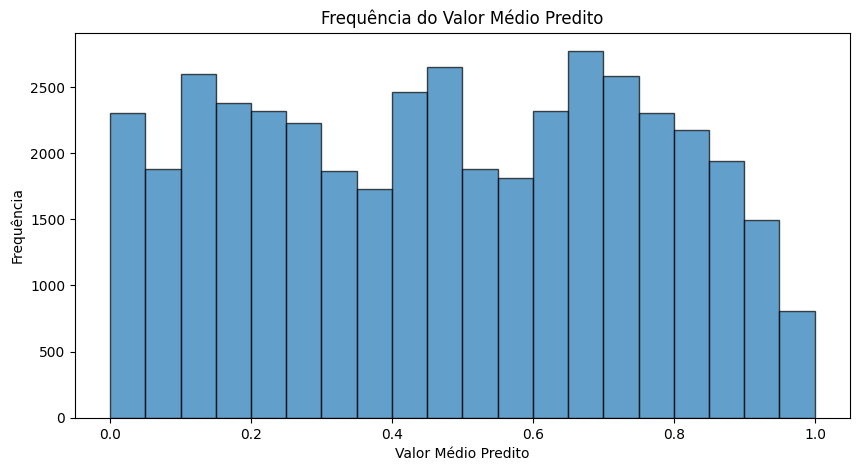

In [64]:
plt.figure(figsize=(10, 5))

prob_true, prob_pred = calibration_curve(y_test, prob_pos, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o', label="Multilayer Perceptron")
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfeita Calibração')

plt.xlabel('Probabilidade Predita')
plt.ylabel('Frequência Real')
plt.title('Gráfico de Calibração')
plt.legend()
plt.show()

# Área sob a curva ROC
fpr, tpr, _ = roc_curve(y_test, prob_pos)
roc_auc = roc_auc_score(y_test, prob_pos)

plt.figure(figsize=(10, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

# Gráfico de Frequência do Valor Médio Predito
plt.figure(figsize=(10, 5))
plt.hist(prob_pos, bins=20, edgecolor='k', alpha=0.7)
plt.xlabel('Valor Médio Predito')
plt.ylabel('Frequência')
plt.title('Frequência do Valor Médio Predito')
plt.show()

# Comparando resultados dos modelos

In [70]:
# Variável que irá armazenar as métricas de cada model
data = []

# Colunas da tabela final para comparação dos modelos
col_names = ["Modelo", "Accuracy", "Precision", "Recall", "AUC(ROC)"]

## Random Forest

In [71]:
# Carregar modelo treinado do disco
rf_model = joblib.load(Path('trained_models','random_forest_model.pkl'))

# Computar resultados no dataset de teste
prob_pos_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = rf_model.predict(X_test)

# Adicionar dados na tabela final
data.append(
    ["Random Forest", 
     accuracy_score(y_test, y_pred_rf),
     precision_score(y_test, y_pred_rf),
     recall_score(y_test, y_pred_rf),
     roc_auc_score(y_test, prob_pos_rf)]
)

## XGBoost

In [72]:
# Carregar modelo treinado do disco
xgb_model = joblib.load(Path('trained_models','xgboost_model.pkl'))

# Computar resultados no dataset de teste
prob_pos_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)

# Adicionar dados na tabela final
data.append(
    ["XGBoost", 
     accuracy_score(y_test, y_pred_xgb),
     precision_score(y_test, y_pred_xgb),
     recall_score(y_test, y_pred_xgb),
     roc_auc_score(y_test, prob_pos_xgb)]
)

## LightGBM

In [73]:
# Carregar modelo treinado do disco
lgbm_model = joblib.load(Path('trained_models','light_gbm_model.pkl'))

# Computar resultados no dataset de teste
prob_pos_lgbm = lgbm_model.predict_proba(X_test)[:, 1]
y_pred_lgbm = lgbm_model.predict(X_test)

# Adicionar dados na tabela final
data.append(
    ["LightGBM", 
     accuracy_score(y_test, y_pred_lgbm),
     precision_score(y_test, y_pred_lgbm),
     recall_score(y_test, y_pred_lgbm),
     roc_auc_score(y_test, prob_pos_lgbm)]
)

## CatBoost

In [76]:
# Carregar modelo treinado do disco
catboost_model = joblib.load(Path('trained_models','catboost_model.pkl'))

# Computar resultados no dataset de teste
prob_pos_catboost = catboost_model.predict_proba(X_test)[:, 1]
y_pred_catboost = catboost_model.predict(X_test)

# Adicionar dados na tabela final
data.append(
    ["CatBoost", 
     accuracy_score(y_test, y_pred_catboost),
     precision_score(y_test, y_pred_catboost),
     recall_score(y_test, y_pred_catboost),
     roc_auc_score(y_test, prob_pos_catboost)]
)

## Multilayer Perceptron

In [89]:
# Instanciar modelo
input_size = 67
hidden_size1 = 128
hidden_size2 = 128
hidden_size3 = 128
num_classes = 1
dropout_rate = 0.5  

mlp_model = MimicAdmissionClassifier(
    input_size=input_size,
    hidden_size1=hidden_size1,
    hidden_size2=hidden_size2,
    hidden_size3=hidden_size3,
    num_classes=num_classes,
    dropout_rate=dropout_rate,
    activation_fn=nn.ReLU,  
    dtype=torch.float64  
)

# Carregar pesos do modelo do disco
mlp_model.load_state_dict(torch.load(Path('trained_models','mimic_admission_classifier_final.pt'), weights_only=True))

# Avaliar performance do modelo no dataset de teste
mlp_model.eval()

threshold = 0.5
prob_pos_mlp = []
y_pred_mlp = []

for inputs, labels in test_dataset:
    outputs = mlp_model(inputs)
    prob_pos_mlp.append(outputs.item())
    y_pred_mlp.append(outputs.item()>threshold)

# Adicionar dados na tabela final
data.append(
    ["MLP", 
     accuracy_score(y_test, y_pred_mlp),
     precision_score(y_test, y_pred_mlp),
     recall_score(y_test, y_pred_mlp),
     roc_auc_score(y_test, prob_pos_mlp)]
)

C:\Users\Vinicius\AppData\Local\Temp\ipykernel_25344\2067220621.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  inputs = torch.tensor(self.mimic_df_X.iloc[idx], dtype=torch.float64)
C:\Users\Vinicius\AppData\Local\Temp\ipykernel_25344\2067220621.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  labels = torch.tensor(self.mimic_df_y.iloc[idx], dtype=torch.float64)


## Tabela comparando modelos

In [93]:
pd.set_option('display.float_format', lambda x: '%2f' % x) # tabela com três casas decimais

print('Resultados para conjunto de teste.')
df_results = pd.DataFrame(data, columns = col_names) # transformando os resultados do teste em um data.frame

# função para destacarmos os maiores valores em cada uma das métricas
def highlight_max(s):
    if s.dtype == object:  # Uso do tipo `object` diretamente
        is_max = [False for _ in range(s.shape[0])]  # Declarando que quando o tipo de dado for objeto, não aplicaremos o highlight
    else:
        is_max = s == s.max()
    return ['background: yellow' if cell else '' for cell in is_max]

# Aplicar a função de destaque ao DataFrame
df_results_styled = df_results.style.apply(highlight_max)
df_results_styled


Resultados para conjunto de teste.


,Modelo,Accuracy,Precision,Recall,AUC(ROC)
0,Random Forest,0.732198,0.728959,0.701155,0.804009
1,XGBoost,0.751841,0.736413,0.749914,0.831271
2,LightGBM,0.752147,0.736829,0.750012,0.831469
3,CatBoost,0.752005,0.737211,0.748734,0.831997
4,MLP,0.748147,0.739931,0.730548,0.828556


# Aplicar seletor de variáveis - Boruta

In [4]:
from boruta import BorutaPy

class CatBoostWrapper:
    def __init__(self, iterations=100):
        self.model = CatBoostClassifier(iterations=iterations, silent=True, task_type='GPU')
    
    def fit(self, X, y):
        self.model.fit(X, y)
    
    def transform(self, X):
        return X

    @property
    def feature_importances_(self):
        return self.model.get_feature_importance()

    # Add get_params method
    def get_params(self, deep=True):
        # Only return iterations to avoid conflicts
        return {"iterations": self.model.get_params()["iterations"]}
    
    # Add set_params method
    def set_params(self, **params):
        # Only allow iterations to be set, preventing conflicts
        if "iterations" in params:
            self.model.set_params(iterations=params["iterations"])
        return self


def apply_boruta_with_catboost(X, y):
    # Create an instance of BorutaPy
    catboost_wrapper = CatBoostWrapper(iterations=100)
    boruta_selector = BorutaPy(catboost_wrapper, n_estimators='auto', verbose=2, random_state=42)
    
    # Fit Boruta to your data
    boruta_selector.fit(X.values, y.values)
    
    # Get the important features
    selected_features = X.columns[boruta_selector.support_].to_list()
    tentative_features = X.columns[boruta_selector.support_weak_].to_list()
    remove_features = list(set(X.columns) - set(selected_features) - set(tentative_features))
    
    return selected_features, tentative_features, remove_features


# Converter para int colunas bool para evitar erros de encoding
X_train_clean = X_train.astype({col: 'int' for col in X_train.select_dtypes('bool').columns})


# Assuming your data is in X (features) and y (target)
selected_features, tentative_features, remove_features = apply_boruta_with_catboost(X_train_clean, y_train)

print("Selected Features:", selected_features)
print("Tentative Features:", tentative_features)
print("To remove Features:", remove_features)

c:\Users\Vinicius\OneDrive\Documentos\GitHub\mimic-iv-machine-learning-project\venv\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Vinicius\OneDrive\Documentos\GitHub\mimic-iv-machine-learning-project\venv\Lib\site-packages\boruta\boruta_py.py:460: UserWarning: The estimator does not have a max_depth property, as a result  the number of trees to use cannot be estimated automatically.
  warnings.warn(


Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	67
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	67
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	67
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	67
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	67
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	67
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	67
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	25
Tentative: 	8
Rejected: 	34
Iteration: 	9 / 100
Confirmed: 	25
Tentative: 	8
Rejected: 	34
Iteration: 	10 / 100
Confirmed: 	25
Tentative: 	8
Rejected: 	34
Iteration: 	11 / 100
Confirmed: 	25
Tentative: 	8
Rejected: 	34
Iteration: 	12 / 100
Confirmed: 	25
Tentative: 	8
Rejected: 	34
Iteration: 	13 / 100
Confirmed: 	25
Tentative: 	8
Rejected: 	34
Iteration: 	14 / 100
Confirmed: 	25
Tentative: 	8
Rejected: 	34
Iteration: 	15 / 100
Confirmed: 	25
Tentative: 	8
Rejected: 	34
Iteration: 	16 / 100
Confirmed: 	26
Tentative: 	7
Reject

### Comentários sobre seleção de variáveis
*Variáveis selecionadas*
- Apenas algumas raças se mostraram variáveis importantes
- Gênero
- Transporte de chegada no departamento de emergência
- Hora do dia
- sinais vitais
- idade
- missing de temperatura, frequência cardíaca, frequência respiratória, nível de urgência
- número de medicamentos ou uso de nenhum medicamento
- target encoding baseado nos medicamentos em uso

*Variáveis rejeitadas*
- mês do ano, dia da semana
- várias raças
- missing de dor, SpO2, pressão arterial sistólica e diastólica, idade

In [6]:
# Treinar modelo com variáveis selecionadas com Boruta
X_train_boruta = pd.concat([X_train[selected_features], X_val[selected_features]])
X_test_boruta = X_test[selected_features]

y_train_boruta = pd.concat([y_train, y_val])
y_test_boruta = y_test

In [7]:
# Treinar CatBoost
# Definição do modelo
catboost_params = {'border_count': 57, 'depth': 12, 'iterations': 328, 'l2_leaf_reg': 61, 'learning_rate': 0.04433986108055431}

catboost_boruta = CatBoostClassifier(eval_metric='Logloss', silent=True, random_seed=42, use_best_model=False, task_type='GPU', **catboost_params)

# Treinar com dados de treino e validação
catboost_boruta.fit(
    X = X_train_boruta,
    y = y_train_boruta.values.ravel()
)

In [9]:
# Avaliar performance do modelo após seleção de variáveis com Boruta
eval(catboost_boruta, model_name='CatBoost pós Boruta', dataset_name='Test', X=X_test_boruta, y=y_test_boruta)

CatBoost pós Boruta Model - Test dataset
Accuracy: 0.7525
Precision: 0.7376
Recall: 0.7497
AUC: 0.8319
              precision    recall  f1-score   support

           0       0.77      0.76      0.76     22164
           1       0.74      0.75      0.74     20345

    accuracy                           0.75     42509
   macro avg       0.75      0.75      0.75     42509
weighted avg       0.75      0.75      0.75     42509



**Performance do CatBoost manteve-se praticamente intocada mesmo após do treino apenas com variáveis selecionadas por Boruta**

# Análise de explicabilidade de predições com SHAP (SHapley Additive exPlanations)

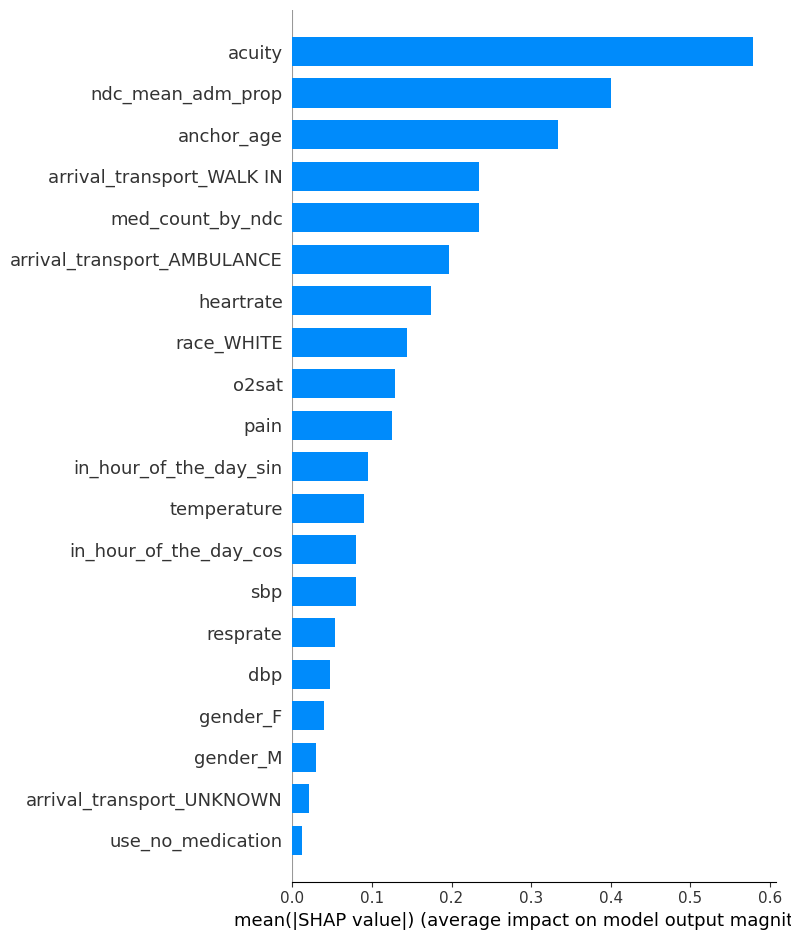

In [11]:
import shap
import joblib

# Carregar modelo treinado do disco
catboost_model = joblib.load(Path('trained_models','catboost_model.pkl'))

# resultados no teste
shap_values_test = shap.TreeExplainer(catboost_model).shap_values(X_test)
shap.summary_plot(shap_values_test, X_test, plot_type="bar")

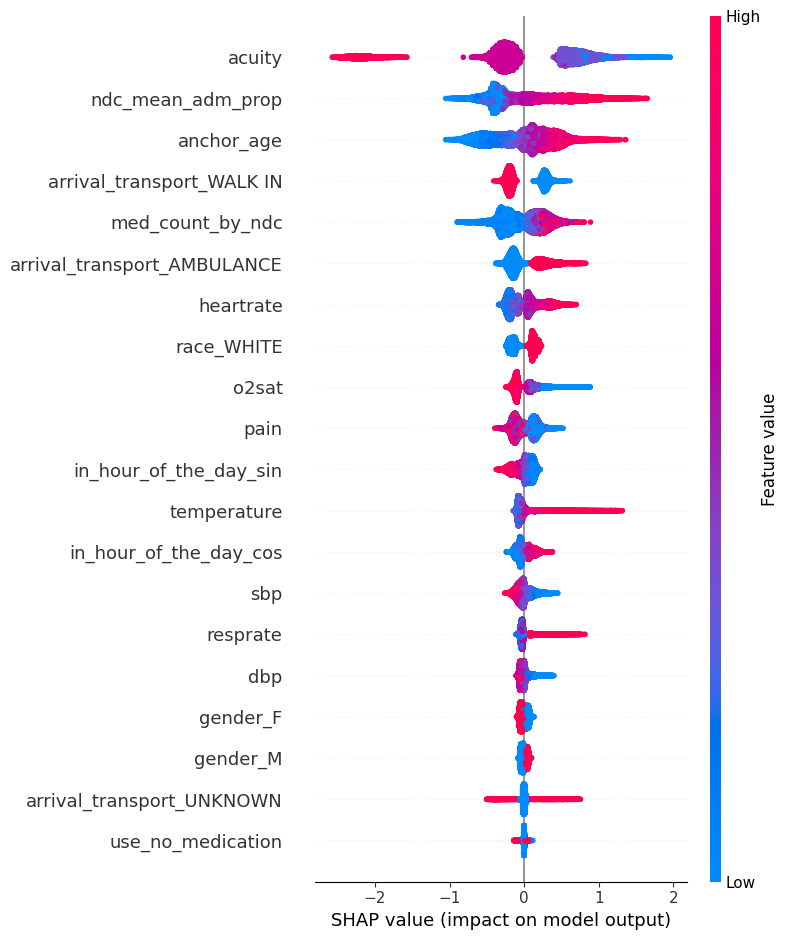

In [12]:
shap.summary_plot(shap_values_test, X_test)